In [1]:
import pandas as pd
import sqlite3

def dados_bancos():
    conn = sqlite3.connect('dados/banking.db')

    financial_indicators = ['ano', 'cnpj', 'NOME_INSTITUICAO', 'TAXONOMIA', 'CONTA', 'NOME_CONTA', 'saldo_medio']

    query = f"""
    SELECT 
        {', '.join(financial_indicators)} 
    FROM    
        balancetes_media_ano
    WHERE 
        cnpj IN (
            SELECT cnpj
            FROM balancetes_media_ano
            GROUP BY ano, cnpj
        );"""

    df = pd.read_sql_query(query, conn)

    conn.close()

    df = df.rename(columns={'NOME_INSTITUICAO': 'nome', 'TAXONOMIA': 'taxonomia', 'CONTA': 'conta', 'NOME_CONTA': 'nome_conta', 'saldo_medio': 'saldo'})

    colunas_para_limpar = ['nome_conta', 'taxonomia']

    for col in colunas_para_limpar:
        df[col] = (df[col]
                .str.lower()
                .str.normalize('NFD')
                .str.replace(r'[\u0300-\u036f]', '', regex=True))

    # Padronizando nomes
    df.loc[df['conta'] == 10000007, 'nome_conta'] = "ativo realizavel"
    df.loc[df['conta'] == 16300000, 'nome_conta'] = "financiamentos rurais"
    df.loc[df['conta'] == 16100004, 'nome_conta'] = "emprestimos e direitos creditorios descontados"
    df.loc[df['conta'] == 14100006, 'nome_conta'] = "direitos junto a participantes de sistema de liquidacao e de arranjo de pagamento"
    df.loc[df['conta'] == 20000004, 'nome_conta'] = "ativo permanente"
    df.loc[df['conta'] == 19900005, 'nome_conta'] = "despesas pagas antecipadamente"
    df.loc[df['conta'] == 23300000, 'nome_conta'] = "bens arrendados - arrendamento operacional"
    df.loc[df['conta'] == 17900007, 'nome_conta'] = "(-) provisoes para operacoes de arrendamento mercantil"
    df.loc[df['conta'] == 12600003, 'nome_conta'] = "aplicacoes em moedas estrangeiras"
    #df.loc[df['conta'] == 30000001, 'nome_conta'] = "compensacao ativa"
    df.loc[df['conta'] == 23200007, 'nome_conta'] = "bens arrendados - arrendamento financeiro"
    df.loc[df['conta'] == 13500009, 'nome_conta'] = "vinculado a aquisicao de acoes de empresas estatais"
    df.loc[df['conta'] == 13000004, 'nome_conta'] = "titulos e valores mobiliarios e instrumentos financeiros derivativos"
    df.loc[df['conta'] == 43500000, 'nome_conta'] = "obrigacoes por titulos e valores mobiliarios no exterior"
    df.loc[df['conta'] == 41600005, 'nome_conta'] = "obrigacoes por depositos especiais e de fundos e programas"
    df.loc[df['conta'] == 40000008, 'nome_conta'] = "passivo exigivel"
    df.loc[df['conta'] == 41800001, 'nome_conta'] = "depositos em moedas estrangeiras"
    df.loc[df['conta'] == 41700008, 'nome_conta'] = "ape - depositos especiais"
    df.loc[df['conta'] == 31400002, 'nome_conta'] = "operacoes de risco nivel c"
    df.loc[df['conta'] == 61900008, 'nome_conta'] = "(-) acoes em tesouraria"
    df.loc[df['conta'] == 43200001, 'nome_conta'] = "recursos  de  letras  imobiliarias,  hipotecarias, de credito e similares"
    df.loc[df['conta'] == 43000005, 'nome_conta'] = "recursos de aceites cambiais, letras imobiliarias e hipotecarias, debentures e similares"
    df.loc[df['conta'] == 44100007, 'nome_conta'] = "obrigacoes junto a participantes de sistema de liquidacao e de arranjo de pagamento"
    df.loc[df['conta'] == 44400006, 'nome_conta'] = "relacoes com correspondentes"
    df.loc[df['conta'] == 46200008, 'nome_conta'] = "emprestimos no pais - outras instituicoes"
    df.loc[df['conta'] == 62600008, 'nome_conta'] = "ape - ajustes de avaliacao patrimonial"
    #df.loc[df['conta'] == 90000003, 'nome_conta'] = "compensacao passiva"
    df.loc[df['conta'] == 81500000, 'nome_conta'] = "(-) despesas com titulos e valores mobiliarios e instrumentos financeiros derivativos"
    df.loc[df['conta'] == 62500005, 'nome_conta'] = "ape - reservas de lucros"
    df.loc[df['conta'] == 71500003, 'nome_conta'] = "rendas com titulos e valores mobiliarios e instrumentos financeiros derivativos"
    df.loc[df['conta'] == 70000009, 'nome_conta'] = "resultado credor"
    df.loc[df['conta'] == 62100003, 'nome_conta'] = "ape - recursos de associados poupadores"
    df.loc[df['conta'] == 81200001, 'nome_conta'] = "(-) despesas de obrigacoes por emprestimos e repasses"
    df.loc[df['conta'] == 80000006, 'nome_conta'] = "(-) resultado devedor"
    df.loc[df['conta'] == 49700000, 'nome_conta'] = "operacoes especiais"
    df.loc[df['conta'] == 46400004, 'nome_conta'] = "repasses do pais - instituicoes oficiais"
    df.loc[df['conta'] == 46100005, 'nome_conta'] = "emprestimos no pais - instituicoes oficiais"
    df.loc[df['conta'] == 14500008, 'nome_conta'] = "recursos transferidos para bancos cooperativos, confederacoes ou cooperativas centrais"
    df.loc[df['conta'] == 44500009, 'nome_conta'] = "recursos recebidos de cooperativas filiadas"

    # Conta duplicada
    df = df[df['conta'] != 88000008]
    df = df[df['conta'] != 47100004]
    df = df[df['conta'] != 51100007]
    df = df[df['conta'] != 78100004]
    df = df[df['conta'] != 61000001]

    mapa_contas = (
        df.groupby('conta')['nome_conta']
        .agg(lambda x: x.value_counts().index[0])
        .to_dict()
    )

    novo_mapeamento = {}

    for conta, nome in mapa_contas.items():
        conta_str = str(conta) # Garante que podemos verificar o início
        
        if conta_str.startswith('1'):
            novo_nome = f"ativo realizavel - {nome}"
        elif conta_str.startswith('2'):
            novo_nome = f"ativo permanente - {nome}"
        elif conta_str.startswith('3'):
            novo_nome = f"compensacao ativa - {nome}"
        elif conta_str.startswith('4'):
            novo_nome = f"passivo exigivel - {nome}"
        elif conta_str.startswith('6'):
            novo_nome = f"patrimonio liquido - {nome}"
        elif conta_str.startswith('7'):
            novo_nome = f"resultado credor - {nome}"
        elif conta_str.startswith('8'):
            novo_nome = f"resultado devedor - {nome}"
        elif conta_str.startswith('9'):
            novo_nome = f"compensacao passiva - {nome}"
        else:
            novo_nome = nome # Mantém o original se não houver regra
            
        novo_mapeamento[conta] = novo_nome

    mapa_contas = novo_mapeamento

    df = df.pivot(
        index=['ano', 'cnpj', 'nome', 'taxonomia'],
        columns='conta',
        values='saldo'
    ).reset_index()
    df['ano'] = df['ano'].astype(int)

    # Valor mínimo da conta operações de crédito
    df = df[df[16000001] > 100000]

    # Excluindo instituições

    # Instituições que não captam depósitos do público (não têm o custo $w_3$ real de mercado) e emprestam dinheiro a taxas subsidiadas pelo governo (TJLP, TLP) para desenvolver regiões, e não para maximizar a margem (NIM).
    df = df[df['taxonomia'] != 'banco nacional de desenvolvimento economico social']
    df = df[df['taxonomia'] != 'bancos de desenvolvimento']
    df = df[df['taxonomia'] != 'agencias de fomento ou de desenvolvimento']

    # As cooperativas de crédito não buscam maximizar o lucro (NIM). Por lei, o objetivo delas é operar no "zero a zero" e devolver o excedente financeiro (as "sobras") aos cooperados. O Índice de Lerner de uma Singular será estruturalmente distorcido, vamos manter apenas os bancos cooperativos.
    df = df[df['taxonomia'] != 'cooperativas de credito']

    # Instituições que não fazem intermediação financeira clássica. O negócio delas é cobrar corretagem/taxas de administração para conectar o cliente à bolsa ou a fundos. A margem financeira de juros (NIM) não é a essência do balanço delas.
    df = df[df['taxonomia'] != 'soc. corretora de titulos e valores mobiliarios']
    df = df[df['taxonomia'] != 'soc distribuidora de titulos e valores mobiliarios']
    df = df[df['taxonomia'] != 'sociedades de credito imobiliario']

    # Instituições que são obrigadas por lei a destinar percentuais engessados de sua captação exclusivamente para o crédito habitacional. Como elas não têm liberdade para pivotar a carteira de crédito para onde dá mais lucro, comparar o spread delas com o de um Banco Múltiplo é injusto e estatisticamente ruidoso.
    df = df[df['taxonomia'] != 'sociedade de credito imobiliario']
    df = df[df['taxonomia'] != 'companhias hipotecarias']
    df = df[df['taxonomia'] != 'associacao de poupanca e emprestimos']

    # Por lei, as SCMs são proibidas de captar depósitos do público. Elas só podem emprestar capital próprio ou dinheiro repassado por outras instituições. Sem a capacidade de captar depósitos, a função de custo translogarítmica falha ao calcular o custo marginal delas.
    df = df[df['taxonomia'] != 'sociedade de credito ao microempreendedor']

    colunas_para_inverter = [col for col in df.columns if col not in ['ano', 'cnpj', 'nome', 'taxonomia']]
    colunas_invertidas = []
        # Se o maior valor da coluna for 0 ou negativo, significa que toda a coluna é negativa
    for col in colunas_para_inverter:
        # Calcula o máximo e o mínimo ignorando os vazios explicitamente
        max_val = df[col].max(skipna=True)
        min_val = df[col].min(skipna=True)
        
        # REGRAS PARA INVERTER:
        # 1. pd.notna(max_val): Garante que a coluna não é 100% vazia
        # 2. max_val <= 0: Garante que não há números positivos
        # 3. min_val < 0: Garante que há valores negativos reais (ignora colunas só de Zeros/NaNs)
        
        if pd.notna(max_val) and (max_val <= 0) and (min_val < 0):
            df[col] = df[col] * -1
            colunas_invertidas.append(col)

    df.fillna(0, inplace=True)
    df_inicial = df.copy()
    df_original = df.copy()

    df_inicial = df_inicial.rename(columns=novo_mapeamento)

    # Dividindo os valores pelo Ativo Total (39999993)
    colunas_a_dividir = [col for col in df.columns if col not in ['ano', 'cnpj', 'nome', 'taxonomia', 39999993]]
    for col in colunas_a_dividir:
        df[col] = df[col] / df[39999993]
    df.drop(columns=[39999993, 99999995], inplace=True)

    df_original = df_original.rename(columns=novo_mapeamento)
    df = df.rename(columns=novo_mapeamento)
    df_filtrado_completo = df.copy()

    # Elimina as contas de compensação
    compensacao = df.columns[df.columns.astype(str).str.startswith('compensacao', na=False)]
    df.drop(columns=compensacao, inplace=True)

    df.drop(columns={'ativo realizavel - ativo realizavel', 'ativo permanente - ativo permanente', 'passivo exigivel - passivo exigivel', 'patrimonio liquido - patrimonio liquido', 'resultado credor - resultado credor', 'resultado credor - receitas operacionais', 'passivo exigivel - depositos', 'resultado devedor - (-) resultado devedor', 'resultado devedor - (-) despesas operacionais', 'ativo realizavel - emprestimos e direitos creditorios descontados', 'ativo realizavel - financiamentos', 'ativo realizavel - aplicacoes em operacoes compromissadas', 'ativo realizavel - aplicacoes em depositos interfinanceiros', 'ativo realizavel - depositos bancarios', 'ativo realizavel - reservas livres', 'ativo realizavel - disponibilidades em moedas estrangeiras', 'resultado devedor - (-) imposto de renda', 'ativo realizavel - vinculados a prestacao de garantias', 'ativo realizavel - relacoes interfinanceiras', 'ativo realizavel - creditos vinculados', 'ativo realizavel - rendas a receber', 'resultado devedor - (-) despesas operacionais', 'resultado devedor - (-) despesas administrativas'}, inplace=True)

    colunas_imobilizado = [
    'ativo permanente - imobilizado de uso',
    'ativo permanente - instalacoes, moveis e equipamentos de uso',
    'ativo permanente - intangivel' # Software e marcas
    ]
    df['Macro_Intensidade_Imobilizado'] = df[colunas_imobilizado].sum(axis=1)

    colunas_operacionais = [
        'resultado devedor - (-) outras despesas operacionais',
        'resultado devedor - (-) despesas nao operacionais',
        'ativo realizavel - despesas pagas antecipadamente'
    ]
    df['Macro_Custo_Estrutural'] = df[colunas_operacionais].sum(axis=1)

    colunas_fiscais = [
        'passivo exigivel - cobranca e arrecadacao de tributos e assemelhados',
        'passivo exigivel - sociais e estatutarias',
        'passivo exigivel - fiscais e previdenciarias'
    ]
    df['Macro_Passivo_Fiscal'] = df[colunas_fiscais].sum(axis=1)

    colunas_provisoes = [
        'ativo realizavel - (-) provisoes para operacoes de credito',
        'ativo realizavel - (-) provisoes para outros creditos'
    ]
    df['Macro_Provisoes'] = df[colunas_provisoes].sum(axis=1)

    todas_colunas_burocraticas = colunas_imobilizado + colunas_operacionais + colunas_fiscais + colunas_provisoes
    df = df.drop(columns=todas_colunas_burocraticas, errors='ignore')

    patrimonio_liquido = df.columns[df.columns.astype(str).str.startswith('patrimonio', na=False)]
    df.drop(columns=patrimonio_liquido, inplace=True)

    df.drop(columns={'ativo realizavel - diversos', 'ativo permanente - outros', 'passivo exigivel - outras obrigacoes', 'passivo exigivel - diversas', 'resultado credor - outras receitas operacionais', 'resultado credor - receitas nao operacionais', 'resultado credor - outras receitas nao operacionais', 'resultado devedor - (-) apuracao de resultado', 'ativo realizavel - instrumentos financeiros derivativos', 'ativo permanente - outros investimentos', 'passivo exigivel - recursos  de  letras  imobiliarias,  hipotecarias, de credito e similares', 'passivo exigivel - emprestimos no exterior', 'passivo exigivel - repasses do pais - instituicoes oficiais', 'passivo exigivel - instrumentos financeiros derivativos', 'passivo exigivel - relacoes interdependencias', 'passivo exigivel - recursos em transito de terceiros', 'resultados de exercicios futuros', 'resultado devedor - (-) participacoes no lucro', 'resultado devedor - (-) aprovisionamentos e ajustes patrimoniais', 'receitas de exercicios futuros'}, inplace=True)

    df.drop(columns={'ativo realizavel - caixa', 'ativo permanente - ativo imobilizado de uso', 'ativo permanente - ativos intangiveis'}, inplace=True)

    contas_finais_estrategicas = [
        'ano',
        'ativo realizavel - disponibilidades',
        'ativo realizavel - aplicacoes interfinanceiras de liquidez',
        'ativo realizavel - titulos e valores mobiliarios e instrumentos financeiros derivativos',
        'ativo realizavel - operacoes de credito',
        'ativo realizavel - outros creditos',
        'ativo realizavel - carteira de cambio',
        'ativo permanente - investimentos',
        'passivo exigivel - depositos a vista',
        'passivo exigivel - depositos interfinanceiros',
        'passivo exigivel - depositos a prazo',
        'passivo exigivel - obrigacoes por operacoes compromissadas',
        'passivo exigivel - recursos de aceites cambiais, letras imobiliarias e hipotecarias, debentures e similares',
        'passivo exigivel - obrigacoes por emprestimos e repasses',
        'resultado credor - rendas de operacoes de credito',
        'resultado credor - rendas de cambio',
        'resultado credor - rendas com titulos e valores mobiliarios e instrumentos financeiros derivativos',
        'resultado credor - rendas de prestacao de servicos',
        'resultado credor - rendas de participacoes',
        'resultado devedor - (-) despesas de captacao',
        'resultado devedor - (-) despesas de obrigacoes por emprestimos e repasses',
        'Macro_Intensidade_Imobilizado',
        'Macro_Custo_Estrutural',
        'Macro_Passivo_Fiscal',
        'Macro_Provisoes'
    ]

    return df_inicial, df, df_original, df_filtrado_completo, mapa_contas

df_inicial, df, df_original, df_filtrado_completo, mapa_contas = dados_bancos()


In [2]:
# Eliminando colunas esparsas

def eliminar_colunas_esparsas(df, df_original):
    # 1. Calcular a porcentagem de nulos em cada coluna
    #esparsidade = df.isnull().sum() / len(df)
    esparsidade = (df.isnull() | (df == 0)).sum() / len(df)
    # 2. Visualizar quantas colunas cairiam em diferentes cortes (Opcional, mas útil)
    print(f"Colunas com > 70% de nulos: {sum(esparsidade > 0.70)}")
    print(f"Colunas com > 80% de nulos: {sum(esparsidade > 0.80)}")
    print(f"Colunas com > 90% de nulos: {sum(esparsidade > 0.90)}")
    print(f"Colunas com > 95% de nulos: {sum(esparsidade > 0.95)}")
    print(f"Colunas com > 99% de nulos: {sum(esparsidade > 0.99)}")

    # 3. Definir o limiar
    #limiar_corte = 0.30
    limiar_corte = 0.70
    # limiar_corte = 0.99 (Alterado)

    # Identificar colunas a serem removidas
    colunas_para_remover = esparsidade[esparsidade > limiar_corte].index
    colunas_para_remover = [col for col in colunas_para_remover if col not in ['ano', 'cnpj', 'nome']]
    # 4. Criar o novo dataset filtrado
    df_filtrado = df.drop(columns=colunas_para_remover)
    df_original = df_original.drop(columns=colunas_para_remover)

    print(f"\nDimensão original: {df.shape[1]} colunas")
    print(f"Dimensão após corte de esparsidade: {df_filtrado.shape[1]} colunas")
    df_filtrado.fillna(0, inplace=True)
    return df_filtrado, df_original, colunas_para_remover

df_filtrado, df_original, var_esparsas = eliminar_colunas_esparsas(df, df_original)

Colunas com > 70% de nulos: 81
Colunas com > 80% de nulos: 68
Colunas com > 90% de nulos: 47
Colunas com > 95% de nulos: 34
Colunas com > 99% de nulos: 15

Dimensão original: 116 colunas
Dimensão após corte de esparsidade: 35 colunas


In [3]:
# Análise de Correlação para Identificar Variáveis Redundantes (Corrigido)
import numpy as np
import seaborn as sns

def remover_colunas_redundantes(df_filtrado):
    X = df_filtrado.copy()
    X['chave_r'] = X['ano'].astype(str) + "_" + X['cnpj'].astype(str)    
    X = X.set_index('chave_r')    
    X = X.drop(columns=['cnpj', 'nome', 'taxonomia'], axis=1)
    
    # 1. CORREÇÃO: Fazer a winsorização ANTES da correlação
    # Preenchemos infinitos e aplicamos winsorização p/ que outliers não inflem o Pearson
    X_winsorizado = X.copy()
    X_winsorizado = X_winsorizado.replace([np.inf, -np.inf], np.nan).fillna(0)
    colunas_financeiras = [col for col in X_winsorizado.columns if col not in ['ano']]
    
    for col in colunas_financeiras:
        X_winsorizado[col] = X_winsorizado.groupby('ano')[col].transform(
            lambda x: x.clip(lower=x.quantile(0.01), upper=x.quantile(0.99))
        )
    
    # 2. Correlação (agora nos dados limpos de outliers)
    corr_matrix = X_winsorizado.corr(method='pearson')
    corr_matrix_abs = corr_matrix.abs()
    upper = corr_matrix_abs.where(np.triu(np.ones(corr_matrix_abs.shape), k=1).astype(bool))
    
    threshold = 0.85
    to_drop = [column for column in upper.columns if any(upper[column] > threshold)]

    print(f"\n--- Contas Redundantes a Descartar (Correlação > {threshold}) ---")
    print(f"Número de variáveis sugeridas para remoção: {len(to_drop)}")
    
    df_filtrado.drop(columns=to_drop, inplace=True)
    X.drop(columns=to_drop, inplace=True)
    X.columns = X.columns.astype(str)
    
    # Guardamos X cru (sem Z-score) para uso futuro (evitar dupla padronização)
    return X, df_filtrado, to_drop

X_raw, df_filtrado, var_redundantes = remover_colunas_redundantes(df_filtrado)
variaveis = pd.DataFrame({'Contas': [col for col in X_raw.columns]})



--- Contas Redundantes a Descartar (Correlação > 0.85) ---
Número de variáveis sugeridas para remoção: 7


In [4]:
# Normalização dos dados

def preparar_dados_painel(df, coluna_tempo='ano', p_inf=0.01, p_sup=0.99):
    df_processado = df.copy()
    df_processado = df_processado.replace([np.inf, -np.inf], np.nan).fillna(0)
    colunas_financeiras = [col for col in df_processado.columns if col not in ['ano']]

    for col in colunas_financeiras:
        # A: Winsorização Ano a Ano
        df_processado[col] = df_processado.groupby(coluna_tempo)[col].transform(
            lambda x: x.clip(lower=x.quantile(p_inf), upper=x.quantile(p_sup))
        )
        
        # B: Z-Score Ano a Ano
        df_processado[col] = df_processado.groupby(coluna_tempo)[col].transform(
            lambda x: (x - x.mean()) / x.std() if x.std() > 0 else 0
        )

        # Mean-Centering (Remove o efeito macro temporal, mas preserva a escala)
        #df_processado[col] = df_processado.groupby(coluna_tempo)[col].transform(lambda x: x - x.mean())

    df_processado = df_processado.fillna(0)
    return df_processado

# X_raw já não possui variáveis redundantes.
X_scaled = preparar_dados_painel(X_raw, coluna_tempo='ano', p_inf=0.01, p_sup=0.99)


In [5]:
%load_ext rpy2.ipython

In [6]:
%%R -i X_scaled -o df_resultados_r

library(clustrd)
library(stats)

alpha <- 0.01

# O operador ! inverterá o vetor lógico, selecionando todo o resto
colunas_para_o_modelo <- !(colnames(X_scaled) %in% c("ano"))
dados_filtrados <- X_scaled[, colunas_para_o_modelo]

# 2. Garantir que os dados filtrados sejam uma matriz numérica pura
dados_filtrados <- as.matrix(dados_filtrados)

# =====================================================================
# PASSO 1: Rodar o Factorial K-Means Inicial (com todos os bancos)
# =====================================================================
# TRAVANDO A O VALOR INICIAL (A Garantia de Reprodutibilidade)
set.seed(94)
#set.seed(12345)
#set.seed(777)

resultado_inicial <- cluspca(data = dados_filtrados,
                             nclus = 4,
                             ndim = 3,
                             method = "FKM",
                             center = FALSE, # Mantém a padronização do Python
                             scale = FALSE,  # Mantém a padronização do Python
                             nstart = 100)

escores_fatoriais <- resultado_inicial$obscoord
clusters_iniciais <- resultado_inicial$cluster
centroides <- resultado_inicial$centroid

# =====================================================================
# PASSO 2: Calcular a Distância de Mahalanobis
# =====================================================================
cov_F <- cov(escores_fatoriais)
distancias <- numeric(nrow(dados_filtrados))

for(i in 1:nrow(dados_filtrados)) {
  cluster_idx <- clusters_iniciais[i]
  centroide_atual <- centroides[cluster_idx, ]
  distancias[i] <- mahalanobis(x = escores_fatoriais[i, ], 
                               center = centroide_atual, 
                               cov = cov_F)
}

# =====================================================================
# PASSO 3: Gerar a Coluna de Outliers (Sem excluir ninguém!)
# =====================================================================
corte <- quantile(distancias, 1 - alpha)

# A mágica acontece aqui: cria um vetor de TRUE ou FALSE
is_outlier <- distancias > corte 

cat("Quantidade de Outliers identificados nesta rodada:", sum(is_outlier), "\n")

# =====================================================================
# PASSO 4: Montar o Data Frame para o Python
# =====================================================================

df_resultados_r <- data.frame(
  Cluster = clusters_iniciais,
  Fator_1 = escores_fatoriais[,1],
  Fator_2 = escores_fatoriais[,2],
  Fator_3 = escores_fatoriais[,3],
  Distancia = distancias,
  Mahalanobis_Outlier = is_outlier, # A coluna que usaremos no Pandas!
  row.names = rownames(dados_filtrados)    # Garante que a chave 'ano_cnpj' seja preservada
)


R[write to console]: Loading required package: ggplot2

R[write to console]: Loading required package: grid



  |======================================================================| 100%Quantidade de Outliers identificados nesta rodada: 29 


In [7]:
def ajuste_outliers(df_resultados_r):
    df_resultados_r['cnpj'] = df_resultados_r.index.str.split('_').str[1]
    taxa_outlier = df_resultados_r.groupby('cnpj')['Mahalanobis_Outlier'].mean()

    cnpjs_persistentes = taxa_outlier[taxa_outlier > 0.1].index
    print(f"Bancos excluídos permanentemente da amostra: {len(cnpjs_persistentes)}")

    # CORREÇÃO: Remover outliers do X_raw (base crua) e D   EPOIS padronizar de forma única!
    X_raw['cnpj'] = X_raw.index.str.split('_').str[1]
    X_raw_limpa = X_raw[~X_raw['cnpj'].isin(cnpjs_persistentes)].copy()
    X_raw_limpa = X_raw_limpa.drop(columns=['cnpj'])
    
    # Remove também do X_raw original para não acumular sujeira
    X_raw.drop(columns=['cnpj'], inplace=True, errors='ignore')
    
    return X_raw_limpa, taxa_outlier

X_raw_limpa, taxa_outlier = ajuste_outliers(df_resultados_r)

# Agora sim, padronizamos a base definitivamente (sem amputar dados duas vezes)
X_scaled_limpa = preparar_dados_painel(X_raw_limpa, coluna_tempo='ano', p_inf=0.01, p_sup=0.99)


Bancos excluídos permanentemente da amostra: 17


In [ ]:
'''
%%R -i X_scaled_limpa
library(clustrd)

# Testando para o Average Silhouette Width - ASW

colunas_para_o_modelo <- !(colnames(X_scaled_limpa) %in% c("ano"))
dados_filtrados <- X_scaled_limpa[, colunas_para_o_modelo]

# 2. Garantir que os dados filtrados sejam uma matriz numérica pura
dados_filtrados <- as.matrix(dados_filtrados)
# =====================================================================
# CALIBRAGEM DO MODELO (Tuning)
# =====================================================================
# Vamos testar de 3 a 7 clusters, mantendo 2 fatores, 
# para ver qual maximiza a Silhueta (asw)
set.seed(94)
#set.seed(12345)
#set.seed(777)
calibragem <- tuneclus(data = dados_filtrados, 
                       nclusrange = 3:6,
                       ndimrange = 2:4,
                       method = "FKM", 
                       criterion = "asw",   # "asw" mede Average Silhouette Width, "ch" mede Calinski-Harabasz e "crit" mede Hartingan Statistics
                       center = FALSE,
                       scale = FALSE,
                       nstart = 50)         # Menos inicializações só para o teste rodar mais rápido

# Imprime o sumário mostrando qual foi a melhor combinação encontrada
summary(calibragem)
'''

[1] "Running for 3 clusters and 2 dimensions..."
  |======================================================================| 100%[1] "Running for 4 clusters and 2 dimensions..."
  |======================================================================| 100%[1] "Running for 4 clusters and 3 dimensions..."
  |======================================================================| 100%[1] "Running for 5 clusters and 2 dimensions..."
  |======================================================================| 100%[1] "Running for 5 clusters and 3 dimensions..."
  |======================================================================| 100%[1] "Running for 5 clusters and 4 dimensions..."
  |======================================================================| 100%[1] "Running for 6 clusters and 2 dimensions..."
  |======================================================================| 100%[1] "Running for 6 clusters and 3 dimensions..."
  |====================================================

In [ ]:
'''
%%R -i X_scaled_limpa
library(clustrd)

# Testando com a estatística de Hartingan

colunas_para_o_modelo <- !(colnames(X_scaled_limpa) %in% c("ano"))
dados_filtrados <- as.matrix(X_scaled_limpa[, colunas_para_o_modelo])

# =====================================================================
# PASSO 1: Extrair a matriz de Erros (WCSS) usando criterion = "crit"
# =====================================================================
# Mudamos o range de clusters para 3:7 para termos o k+1 da fórmula
set.seed(94)
calibragem_crit <- tuneclus(data = dados_filtrados, 
                            nclusrange = 3:6, 
                            ndimrange = 1:3,
                            method = "FKM", 
                            criterion = "crit",  # <-- ALTERAÇÃO AQUI (Extrai o WCSS)
                            center = FALSE,
                            scale = FALSE,
                            nstart = 50)

# A matriz com as somas dos quadrados de cada modelo
matriz_wcss <- calibragem_crit$critgrid

# =====================================================================
# CALCULO DA ESTATISTICA DE HARTIGAN (Versão Dinâmica e Robusta)
# =====================================================================

# 1. Recuperar a Matriz Bruta de Erros (WCSS)
matriz_wcss <- calibragem_crit$critgrid

print("=== Matriz de Erros Bruta (WCSS) ===")
print(matriz_wcss)

# 2. Extrair as Dimensões e Clusters automaticamente da própria matriz
# Isso evita NAs por hardcoding (buscar o que não existe)
D_disponiveis <- as.numeric(gsub("X", "", colnames(matriz_wcss)))
K_disponiveis <- as.numeric(rownames(matriz_wcss))

# Só podemos calcular Hartigan até o PENÚLTIMO K (pois precisamos do k+1)
K_testados <- K_disponiveis[-length(K_disponiveis)]
N <- nrow(dados_filtrados)

# 3. Configurar a matriz de resultados
matriz_hartigan <- matrix(NA, nrow = length(K_testados), ncol = length(D_disponiveis))
rownames(matriz_hartigan) <- paste("K =", K_testados)
colnames(matriz_hartigan) <- paste("D =", D_disponiveis)

# 4. O Loop Dinâmico
for (d_idx in 1:length(D_disponiveis)) {
  for (k_idx in 1:length(K_testados)) {
    
    # Extrai os erros por posição (linha k e linha k+1)
    W_k  <- as.numeric(as.character(matriz_wcss[k_idx, d_idx]))
    W_k1 <- as.numeric(as.character(matriz_wcss[k_idx + 1, d_idx]))
    
    k_real <- K_testados[k_idx]
    
    # Previne divisão por zero ou NAs (respeita a regra geométrica D < K)
    if (!is.na(W_k) && !is.na(W_k1) && W_k1 > 0) {
      
      # H = [ (W_k / W_{k+1}) - 1 ] * (N - k - 1)
      H_score <- ((W_k / W_k1) - 1) * (N - k_real - 1)
      
      matriz_hartigan[k_idx, d_idx] <- round(H_score, 2)
    }
  }
}

# 5. Exibir o Resultado Final
print("=== Estatística de Hartigan (Dinâmica) ===")
print(matriz_hartigan)
'''

[1] "Running for 3 clusters and 1 dimensions..."
  |======================================================================| 100%[1] "Running for 3 clusters and 2 dimensions..."
  |======================================================================| 100%[1] "Running for 4 clusters and 1 dimensions..."
  |======================================================================| 100%[1] "Running for 4 clusters and 2 dimensions..."
  |======================================================================| 100%[1] "Running for 4 clusters and 3 dimensions..."
  |======================================================================| 100%[1] "Running for 5 clusters and 1 dimensions..."
  |======================================================================| 100%[1] "Running for 5 clusters and 2 dimensions..."
  |======================================================================| 100%[1] "Running for 5 clusters and 3 dimensions..."
  |====================================================

In [ ]:
'''
%%R -i X_scaled_limpa -o df_hartigan_py

# ... [Todo o seu código de calcular a matriz_hartigan continua aqui exatamente igual] ...

# 5. Exibir o Resultado Final
print("=== Estatística de Hartigan (Dinâmica) ===")
print(matriz_hartigan)

# --- CÓDIGO NOVO PARA EXPORTAR PARA O PYTHON ---
# Transforma a matriz em uma tabela "longa" (dataframe) perfeita para o Python
df_hartigan_py <- as.data.frame(as.table(matriz_hartigan))
colnames(df_hartigan_py) <- c("K", "D", "Hartigan")
'''

[1] "=== Estatística de Hartigan (Dinâmica) ==="
       D = 1   D = 2   D = 3
K = 3 -32.96  -30.71      NA
K = 4 127.38  518.21  -88.29
K = 5  46.83 -241.19  359.59
K = 6 105.08  231.98 -104.08


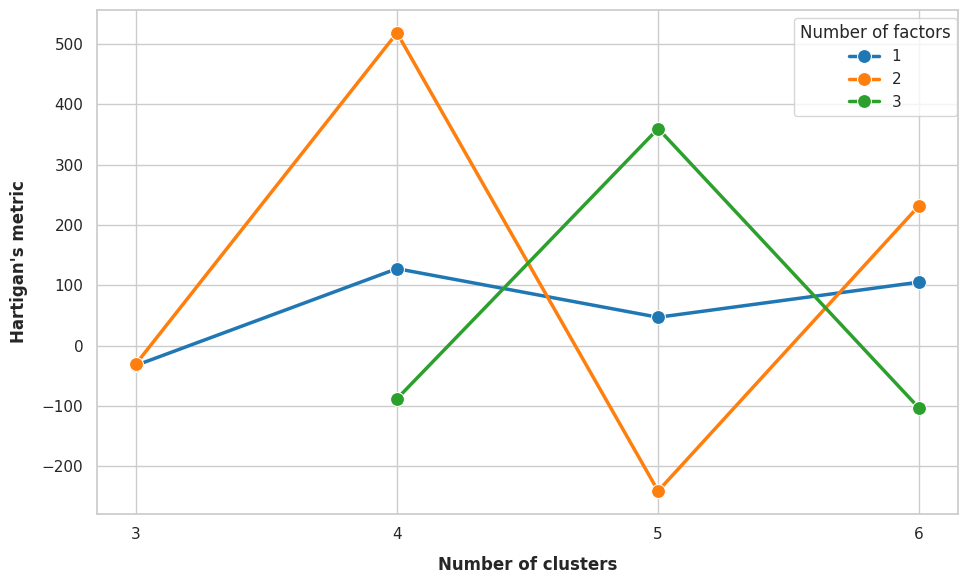

In [ ]:
'''
import matplotlib.pyplot as plt
# 1. Limpeza dos dados exportados do R
# Copiamos o dataframe que veio do R e removemos os NAs (valores vazios)
df_plot = df_hartigan_py.dropna().copy()

# Limpamos os textos para ficarem apenas os números e rótulos limpos
df_plot['K'] = df_plot['K'].str.replace('K = ', '').astype(int)
df_plot['D'] = df_plot['D'].str.replace('D = ', '')

# 2. Configuração do Estilo do Gráfico (Estilo Acadêmico)
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# 3. Plotagem das Linhas e Pontos
ax = sns.lineplot(
    data=df_plot, 
    x='K', 
    y='Hartigan', 
    hue='D', 
    marker='o', 
    markersize=10, 
    linewidth=2.5,
    palette="tab10" # Paleta de cores contrastantes
)

# 4. A Linha de Corte de Hartigan (H = 10)
#plt.axhline(y=10, color='red', linestyle='--', linewidth=2, label='Corte Teórico (H > 10)')

# 5. Textos e Títulos
#plt.title("Hartigan's metric", 
#          fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Number of clusters", fontsize=12, fontweight='bold', labelpad=10)
plt.ylabel("Hartigan's metric", fontsize=12, fontweight='bold', labelpad=10)

# Força o eixo X a mostrar apenas números inteiros
plt.xticks(df_plot['K'].unique())

# 6. Configuração da Legenda
#handles, labels = ax.get_legend_handles_labels()
plt.legend(title="Number of factors", title_fontsize='12', 
           loc='upper left', bbox_to_anchor=(0.8, 1))
#plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')

# 7. Ajuste fino de layout e exibição
plt.tight_layout()
plt.show()

# Opcional: Descomente a linha abaixo para salvar o gráfico em alta resolução
# plt.savefig("grafico_hartigan_fkm_python.png", dpi=300, bbox_inches='tight')
'''

  |======================================================================| 100%

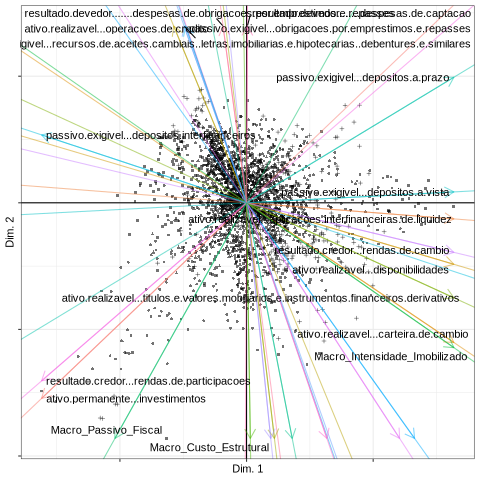

In [8]:
%%R -i X_scaled_limpa -o df_clusters_finais

colunas_para_o_modelo <- !(colnames(X_scaled_limpa) %in% c("ano"))
dados_filtrados <- X_scaled_limpa[, colunas_para_o_modelo]

# 2. Garantir que os dados filtrados sejam uma matriz numérica pura
dados_filtrados <- as.matrix(dados_filtrados)
# =====================================================================
# O MODELO DEFINITIVO (Apenas com a base saudável)
# =====================================================================
# TRAVANDO A O VALOR INICIAL (A Garantia de Reprodutibilidade)
set.seed(94)
#set.seed(12345)
#set.seed(777)

resultado_final <- cluspca(data = dados_filtrados, 
                           nclus = 4,
                           ndim = 3,
                           method = "FKM",
                           center = FALSE,
                           scale = FALSE,
                           nstart = 100)

plot(resultado_final)

# Exportamos para o Python apenas a classificação definitiva
df_clusters_finais <- data.frame(
  Cluster = resultado_final$cluster,
  row.names = rownames(dados_filtrados)
)

In [9]:
%%R
# =====================================================================
# CALCULAR EIGENVALUES E VARIÂNCIA EXPLICADA
# =====================================================================

# 1. Calcula a variância de cada fator (isso matematicamente é o Eigenvalue)
eigenvalues <- apply(resultado_final$obscoord, 2, var)

# 2. Calcula a variância total da base (soma da variância de cada coluna original)
variancia_total <- sum(apply(dados_filtrados, 2, var))

# 3. Calcula o percentual de variância explicada por cada fator
perc_variancia <- (eigenvalues / variancia_total) * 100

# 4. Consolida tudo em um Data Frame limpo e estruturado
df_variancia <- data.frame(
  Fator = paste0("Fator_", 1:length(eigenvalues)),
  Eigenvalue = round(eigenvalues, 4),
  Variancia_Explicada_Perc = round(perc_variancia, 2),
  Variancia_Acumulada_Perc = round(cumsum(perc_variancia), 2),
  row.names = NULL
)

# Imprime o resultado no output da célula
print(df_variancia)

    Fator Eigenvalue Variancia_Explicada_Perc Variancia_Acumulada_Perc
1 Fator_1     1.8561                     7.77                     7.77
2 Fator_2     1.9194                     8.04                    15.81
3 Fator_3     2.4548                    10.28                    26.09


In [10]:
%R -i X_scaled_limpa -o df_clusters_finais -o df_variancia

In [11]:
%%R -o resultado_final

names(resultado_final)

 [1] "obscoord"  "attcoord"  "centroid"  "cluster"   "criterion" "size"     
 [7] "odata"     "scale"     "center"    "nstart"   


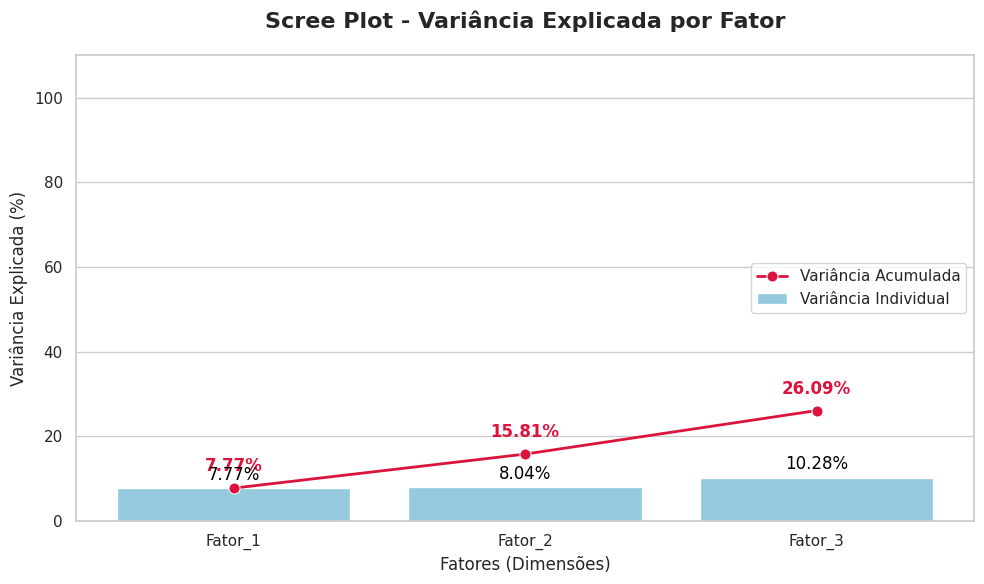

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define o estilo do gráfico
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# 1. Gráfico de Barras: Variância Explicada por cada Fator
sns.barplot(
    data=df_variancia,
    x='Fator',
    y='Variancia_Explicada_Perc',
    color='skyblue',
    label='Variância Individual'
)

# 2. Gráfico de Linha: Variância Acumulada
sns.lineplot(
    data=df_variancia,
    x='Fator',
    y='Variancia_Acumulada_Perc',
    color='crimson',
    marker='o',
    linewidth=2,
    markersize=8,
    label='Variância Acumulada'
)

# 3. Adicionando rótulos de dados (os números) nos pontos da linha
for i in range(len(df_variancia)):
    valor = df_variancia['Variancia_Acumulada_Perc'].iloc[i]
    plt.text(i, valor + 3, f'{valor}%', 
             ha='center', va='bottom', color='crimson', fontweight='bold')

# 4. Adicionando rótulos de dados dentro das barras
for i in range(len(df_variancia)):
    valor = df_variancia['Variancia_Explicada_Perc'].iloc[i]
    plt.text(i, valor + 1, f'{valor}%', 
             ha='center', va='bottom', color='black')

# Ajustes visuais (Títulos, Eixos e Legenda)
plt.title('Scree Plot - Variância Explicada por Fator', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Fatores (Dimensões)', fontsize=12)
plt.ylabel('Variância Explicada (%)', fontsize=12)
plt.ylim(0, 110) # Espaço extra no topo para o texto não cortar

plt.legend(loc='center right')
plt.tight_layout()

# Exibe o gráfico
plt.show()

In [13]:

def adicionar_clusters(df_filtrado_completo, df_inicial, df_filtrado, df_clusters_finais):
    df_inicial['chave_r'] = df_inicial['ano'].astype(str) + "_" + df_inicial['cnpj'].astype(str)
    df_inicial = df_inicial.set_index('chave_r')

    base_para_regressao = df_inicial.merge(
        df_clusters_finais, 
        left_index=True, 
        right_index=True, 
        how='left'
    )

    base_para_regressao = base_para_regressao.reset_index()
    colunas_ordenadas = ['ano', 'cnpj'] + [col for col in base_para_regressao.columns if col not in ['ano', 'cnpj']]
    base_para_regressao = base_para_regressao[colunas_ordenadas]

    colunas_cluster = base_para_regressao[['ano', 'cnpj', 'Cluster']]

    df_inicial = pd.merge(
        df_inicial, 
        colunas_cluster, 
        on=['ano', 'cnpj'],  # Exige que a combinação de Ano e CNPJ seja exata
        how='left'           # O 'left' mantém a estrutura original do df
    )

    coluna_para_mover = df_inicial.pop('Cluster')
    df_inicial.insert(4, 'Cluster', coluna_para_mover)

    outliers = df_inicial[df_inicial['Cluster'].isna()].copy()
    outliers.drop(columns=['Cluster'], inplace=True)

    df_inicial = df_inicial[df_inicial['Cluster'].notna()].copy()
    df_inicial['Cluster'] = df_inicial['Cluster'].astype(int)

    df_filtrado = pd.merge(
        df_filtrado, 
        colunas_cluster, 
        on=['ano', 'cnpj'],
        how='left'
    )
    coluna_para_mover = df_filtrado.pop('Cluster')
    df_filtrado.insert(4, 'Cluster', coluna_para_mover)

    df_filtrado_completo = pd.merge(
        df_filtrado_completo, 
        colunas_cluster, 
        on=['ano', 'cnpj'],
        how='left'
    )
    coluna_para_mover = df_filtrado_completo.pop('Cluster')
    df_filtrado_completo.insert(4, 'Cluster', coluna_para_mover)
    df_filtrado_completo = df_filtrado_completo[df_filtrado_completo['Cluster'].notna()].copy()
    df_filtrado_completo['Cluster'] = df_filtrado_completo['Cluster'].astype(int)
    df_filtrado_completo = df_filtrado_completo[df_filtrado_completo['Cluster'].notna()].copy()

    outliers_filtrados = df_filtrado[df_filtrado['Cluster'].isna()].copy()
    outliers_filtrados.drop(columns=['Cluster'], inplace=True)
    
    df_filtrado = df_filtrado[df_filtrado['Cluster'].notna()].copy()
    df_filtrado['Cluster'] = df_filtrado['Cluster'].astype(int)


    return df_filtrado_completo, df_inicial, outliers, df_filtrado, outliers_filtrados

df_filtrado_completo, df_inicial, df_outliers, df_filtrado, df_outliers_filtrados = adicionar_clusters(df_filtrado_completo, df_inicial, df_filtrado, df_clusters_finais)

bancos_anomalos = df_outliers['nome'].value_counts()
anos_anomalos = df_outliers['ano'].value_counts()


In [14]:
def loadings(resultado_final):
    pesos_variaveis = np.array(resultado_final['attcoord'])
    colunas_financeiras = [col for col in X_scaled_limpa.columns if col not in ['ano']]
    # Criando o DataFrame para facilitar a leitura
    loadings = pd.DataFrame(
        pesos_variaveis,
        columns=['Fator_1', 'Fator_2', 'Fator_3'],
        index=colunas_financeiras # O nome das suas variáveis contábeis originais
    )
    return loadings

loadings = loadings(resultado_final)
#loadings.to_csv('loadings_fatores.csv', sep=';', index=True)
#loadings.to_clipboard(index= True)


In [15]:
%%R -o coordenadas

# 1. Extrair os clusters e os escores do modelo limpo
clusters_finais <- resultado_final$cluster
fator_1 <- resultado_final$obscoord[,1]
fator_2 <- resultado_final$obscoord[,2]
fator_3 <- resultado_final$obscoord[,3]

# 2. O Segredo: Montar o Data Frame forçando o rownames original
coordenadas <- data.frame(
  Cluster = clusters_finais,
  Fator_1 = fator_1,
  Fator_2 = fator_2,
  Fator_3 = fator_3,
  row.names = rownames(X_scaled_limpa)  # <-- Isso garante que o índice não se perca!
)


In [16]:
def plotar_clusters(coordenadas):
    coordenadas = coordenadas.reset_index()
    coordenadas['ano'] = coordenadas['index'].str.split('_').str[0]
    coordenadas['ano'] = coordenadas['ano'].astype(int)
    coordenadas.insert(0, 'ano', coordenadas.pop('ano'))
    coordenadas['cnpj'] = coordenadas['index'].str.split('_', expand=True)[1].str.strip()
    coordenadas.insert(1, 'cnpj', coordenadas.pop('cnpj'))
    coordenadas = coordenadas.drop(columns='index')
    
    return(coordenadas)

coordenadas = plotar_clusters(coordenadas)

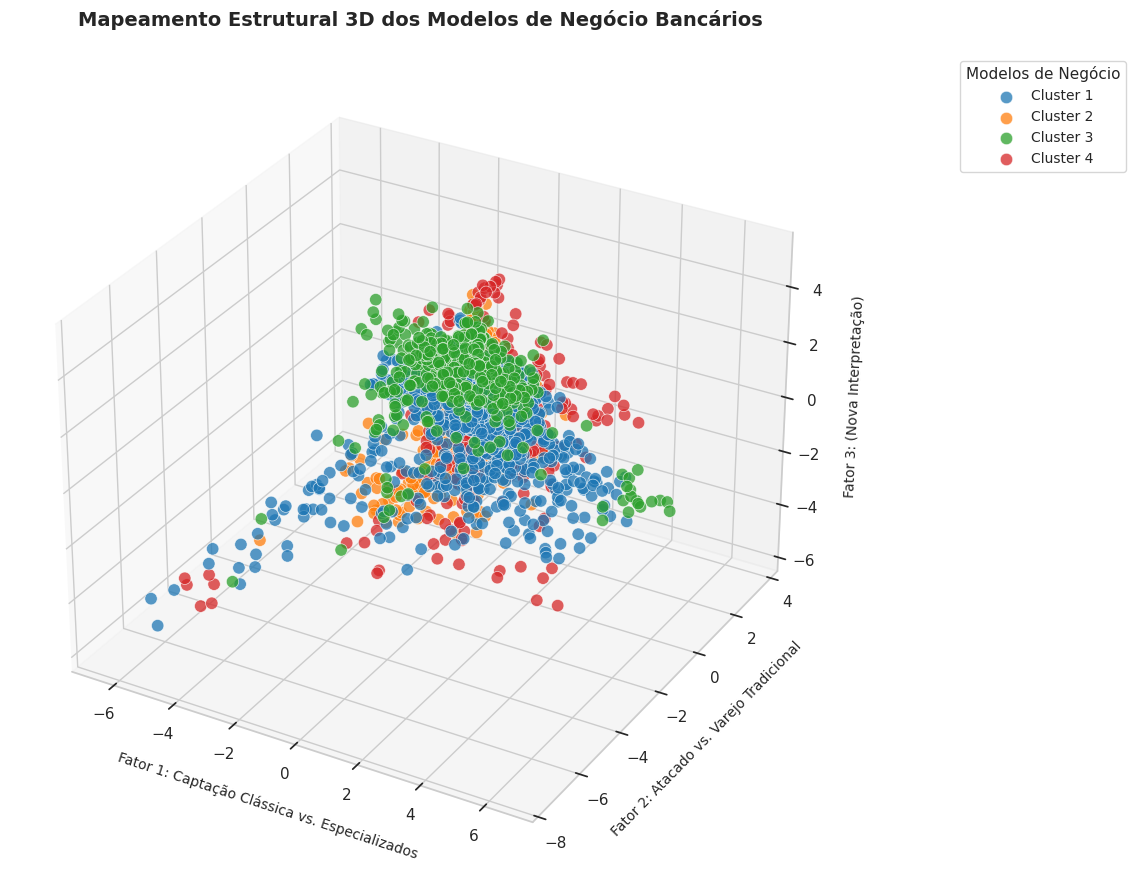

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

def plotar_clusters_3d(coordenadas):
    # 1. Definir o estilo visual
    sns.set_theme(style="whitegrid")
    
    # 2. Criar a figura e avisar o Matplotlib que o eixo é 3D
    fig = plt.figure(figsize=(12, 9))
    ax = fig.add_subplot(111, projection='3d')

    # 3. Preparar as cores (Substituindo o 'hue' do Seaborn)
    # Garante que a coluna Cluster seja tratada como categoria (texto)
    coordenadas['Cluster'] = coordenadas['Cluster'].astype(str)
    clusters_unicos = sorted(coordenadas['Cluster'].unique())
    paleta = sns.color_palette('tab10', n_colors=len(clusters_unicos))

    # 4. Plotar cada cluster separadamente para gerar a legenda correta
    for i, cluster in enumerate(clusters_unicos):
        dados_cluster = coordenadas[coordenadas['Cluster'] == cluster]
        
        ax.scatter(
            dados_cluster['Fator_1'],
            dados_cluster['Fator_2'],
            dados_cluster['Fator_3'],
            label=f'Cluster {cluster}',
            color=paleta[i],
            alpha=0.75,
            s=80,             # Tamanho dos pontos (reduzido levemente para 3D)
            edgecolor='w',
            linewidth=0.5
        )

    # 5. Customizar os títulos e rótulos
    ax.set_title('Mapeamento Estrutural 3D dos Modelos de Negócio Bancários', fontsize=14, fontweight='bold', pad=20)
    ax.set_xlabel('Fator 1: Captação Clássica vs. Especializados', fontsize=10, labelpad=10)
    ax.set_ylabel('Fator 2: Atacado vs. Varejo Tradicional', fontsize=10, labelpad=10)
    ax.set_zlabel('Fator 3: (Nova Interpretação)', fontsize=10, labelpad=10)

    # 6. Ajustar a legenda
    ax.legend(
        title='Modelos de Negócio', 
        bbox_to_anchor=(1.15, 1), 
        loc='upper left', 
        fontsize=10,
        title_fontsize=11
    )

    # 7. Exibir o gráfico
    plt.tight_layout()
    plt.show()

plotar_clusters_3d(coordenadas)

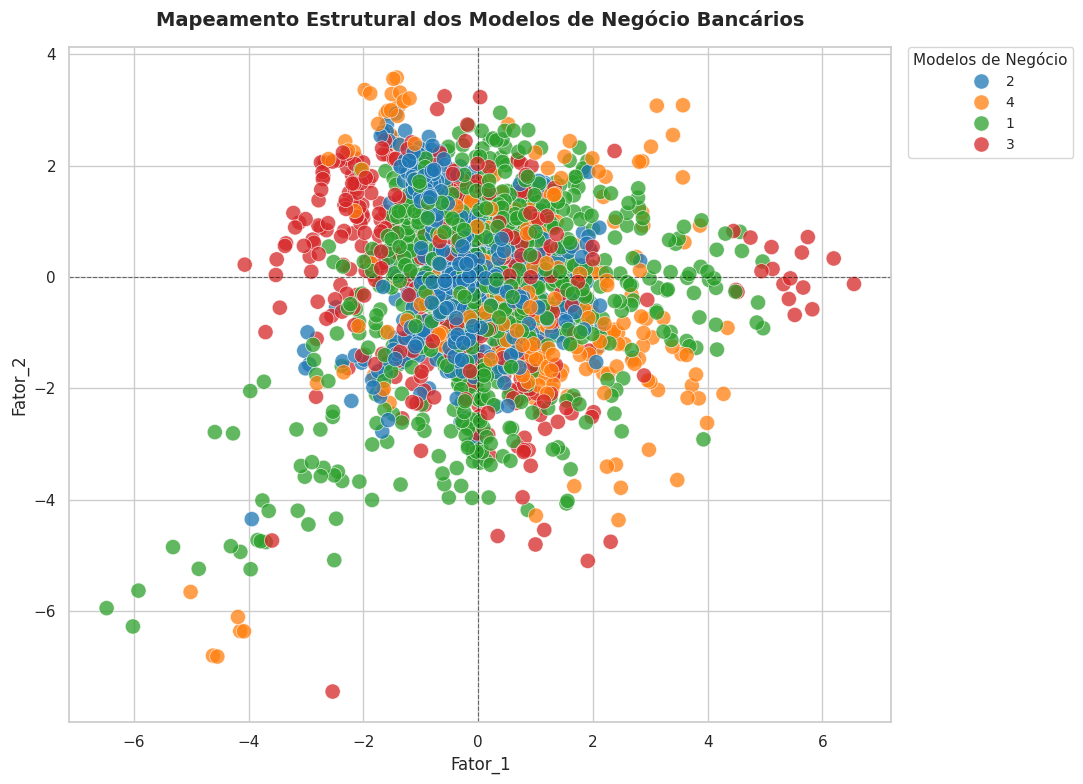

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

def plotar_clusters(coordenadas):
    # 1. Definir o estilo visual do gráfico
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(11, 8))

    # 2. Criar o gráfico de dispersão
    # O parâmetro 'hue' faz a mágica de colorir por cluster automaticamente
    grafico = sns.scatterplot(
        data=coordenadas,
        x='Fator_1',
        y='Fator_2',
        hue='Cluster',          # Coluna que define as cores
        palette='tab10',        # Paleta de cores distintas para variáveis categóricas
        alpha=0.75,             # Transparência para pontos sobrepostos
        s=120,                  # Tamanho dos pontos
        edgecolor='w',          # Contorno branco nos pontos para destacá-los
        linewidth=0.5
    )

    # 3. Adicionar linhas cruzadas no zero (eixos cartesianos)
    # Isso ajuda visualmente a dividir os 4 quadrantes dos modelos de negócio
    plt.axhline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
    plt.axvline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)

    # 4. Customizar os títulos e rótulos dos eixos com os significados econômicos
    plt.title('Mapeamento Estrutural dos Modelos de Negócio Bancários', fontsize=14, fontweight='bold', pad=15)
    #plt.xlabel('Fator 1: Tesouraria e Atacado (+) vs. Varejo Tradicional (-)', fontsize=11, labelpad=10)
    #plt.ylabel('Fator 2: Risco e Inadimplência (+) vs. Liquidez e Segurança (-)', fontsize=11, labelpad=10)

    # 5. Ajustar a legenda para que ela fique limpa e fora da área de plotagem
    plt.legend(
        title='Modelos de Negócio', 
        bbox_to_anchor=(1.02, 1), 
        loc='upper left', 
        borderaxespad=0,
        fontsize=10,
        title_fontsize=11
    )

    # 6. Otimizar o espaçamento para não cortar textos
    plt.tight_layout()

    # 7. Exibir o gráfico no Jupyter Notebook
    plt.show()

plotar_clusters(coordenadas)

In [19]:
def criar_clusters_fixos_sem_empates(coordenadas, tabela_bancos_cortados):
    coordenadas_clusters_fixos = coordenadas.copy(deep=True)

    # 2. Calcula a proporção do cluster mais frequente para cada banco
    # O value_counts(normalize=True) gera as porcentagens ordenadas do maior para o menor.
    # O .iloc[0] pega a porcentagem do cluster que mais apareceu (a moda principal).
    proporcao_moda = coordenadas_clusters_fixos.groupby('cnpj')['Cluster'].apply(
        lambda x: x.value_counts(normalize=True).iloc[0] if not x.empty else 0
    )

    # 3. Define a regra de corte e isola os CNPJs aprovados
    limite = 0.70
    cnpjs_com_moda_clara = proporcao_moda[proporcao_moda >= limite].index

    coordenadas_clusters_excluidos = coordenadas_clusters_fixos[~coordenadas_clusters_fixos['cnpj'].isin(cnpjs_com_moda_clara)].copy()

    # 4. Corta da base todos os bancos que não passaram no teste
    coordenadas_clusters_fixos = coordenadas_clusters_fixos[coordenadas_clusters_fixos['cnpj'].isin(cnpjs_com_moda_clara)].copy()

    # com a base limpa de indecisos, fixamos a moda para todos os anos do banco
    coordenadas_clusters_fixos['Cluster'] = coordenadas_clusters_fixos.groupby('cnpj')['Cluster'].transform(lambda x: x.mode()[0])

    # Imprimir o impacto do corte
    bancos_totais = len(proporcao_moda)
    bancos_cortados = bancos_totais - len(cnpjs_com_moda_clara)
    print(f"Bancos excluídos por falta de moda clara: {bancos_cortados}")

    if tabela_bancos_cortados == 1:
        return coordenadas_clusters_fixos, coordenadas_clusters_excluidos
    else:
        return coordenadas_clusters_fixos

df_inicial_clusters_fixos = criar_clusters_fixos_sem_empates(df_inicial, 0)
df_filtrado_clusters_fixos, bancos_sem_moda = criar_clusters_fixos_sem_empates(df_filtrado, 1)
coordenadas_clusters_fixos = criar_clusters_fixos_sem_empates(coordenadas, 0)


Bancos excluídos por falta de moda clara: 91
Bancos excluídos por falta de moda clara: 91
Bancos excluídos por falta de moda clara: 91


In [20]:

def criar_tabela_diff_bancos(df_filtrado, df_filtrado_clusters_fixos):
    df_comparacao = df_filtrado[['Cluster']].merge(
        df_filtrado_clusters_fixos[['Cluster']], 
        left_index=True, 
        right_index=True, 
        suffixes=('_original', '_fixado')
    )

    mascara_mudanca = df_comparacao['Cluster_original'] != df_comparacao['Cluster_fixado']

    df_mudou_cluster = df_comparacao[mascara_mudanca]
    tabela_completa_mudancas = df_filtrado.loc[df_mudou_cluster.index]
    tabela_completa_mudancas['Cluster_fixado'] = df_comparacao['Cluster_fixado']

    cluster_fixado = tabela_completa_mudancas.pop('Cluster_fixado')
    tabela_completa_mudancas.insert(5, 'Cluster_fixado', cluster_fixado)

    return tabela_completa_mudancas

mudancas_cluster = criar_tabela_diff_bancos(df_filtrado, df_filtrado_clusters_fixos)

contagem_mudancas_cluster = mudancas_cluster.reset_index().groupby(['cnpj']).size()

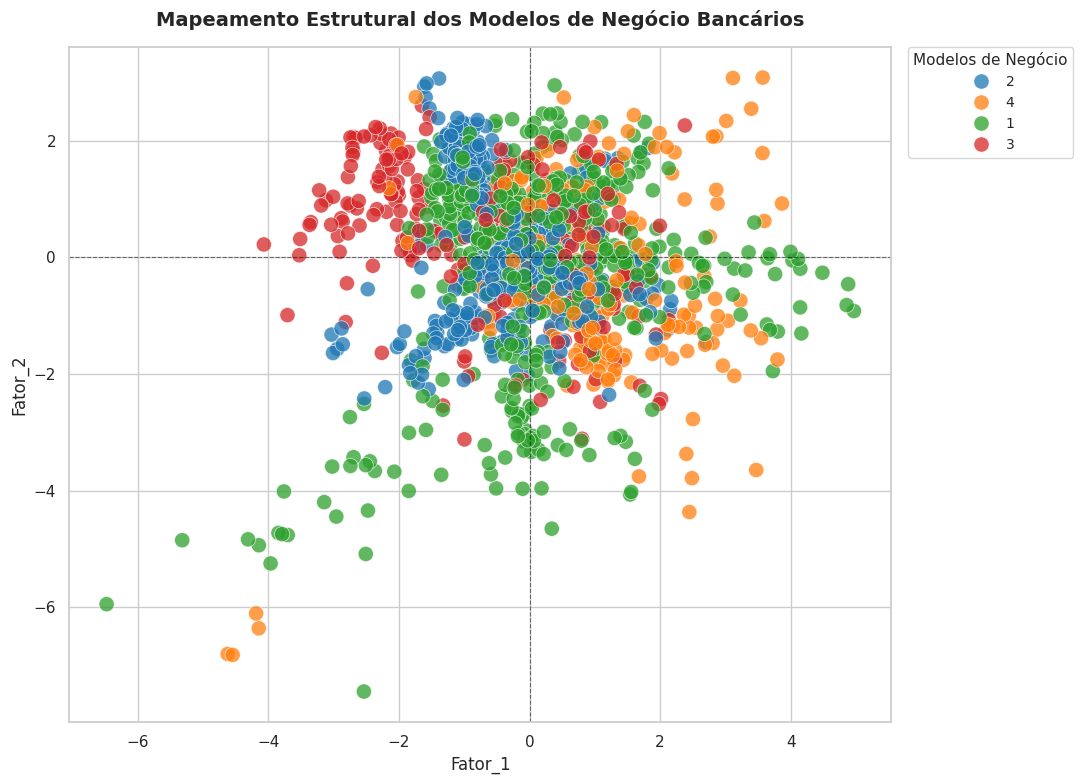

In [21]:

plotar_clusters(coordenadas_clusters_fixos)

In [22]:
def criar_clusters_fixos(coordenadas):
    df_fixo = coordenadas.copy(deep=True)
    empates_resolvidos = 0
    
    # Dicionário para armazenar o cluster definitivo de cada banco
    mapa_clusters = {}
    
    # Ordena a base inteira por ano primeiro
    # Isso garante que a última linha de cada grupo (iloc[-1]) seja realmente a mais recente
    if 'ano' in df_fixo.columns:
        df_fixo = df_fixo.sort_values(['cnpj', 'ano'])
        
    for cnpj, grupo in df_fixo.groupby('cnpj'):
        modas = grupo['Cluster'].mode()
        
        if len(modas) == 1:
            # Há uma moda estatística clara, o banco segue ela
            mapa_clusters[cnpj] = modas.iloc[0]
        else:
            # Empate! Ignoramos a moda e pegamos o cluster do último ano registrado
            mapa_clusters[cnpj] = grupo['Cluster'].iloc[-1]
            empates_resolvidos += 1
            
    # Sobrescreve a coluna Cluster original com os clusters definitivos fixados
    df_fixo['Cluster'] = df_fixo['cnpj'].map(mapa_clusters)
    
    # Imprime o log de impacto para controle da dissertação
    total_bancos = len(mapa_clusters)
    bancos_claros = total_bancos - empates_resolvidos
    
    print("=== Tratamento Longitudinal de Clusters ===")
    print(f"Total de CNPJs únicos analisados: {total_bancos}")
    print(f"Bancos com moda clara mantidos: {bancos_claros}")
    print(f"Bancos empatados resolvidos pelo ano mais recente: {empates_resolvidos}")
    print(f"Bancos excluídos: 0")
    
    return df_fixo

#df_inicial_clusters_fixos = criar_clusters_fixos(df_inicial)
#df_filtrado_clusters_fixos = criar_clusters_fixos(df_filtrado)
#coordenadas_clusters_fixos = criar_clusters_fixos(coordenadas)
#plotar_clusters(coordenadas_clusters_fixos)


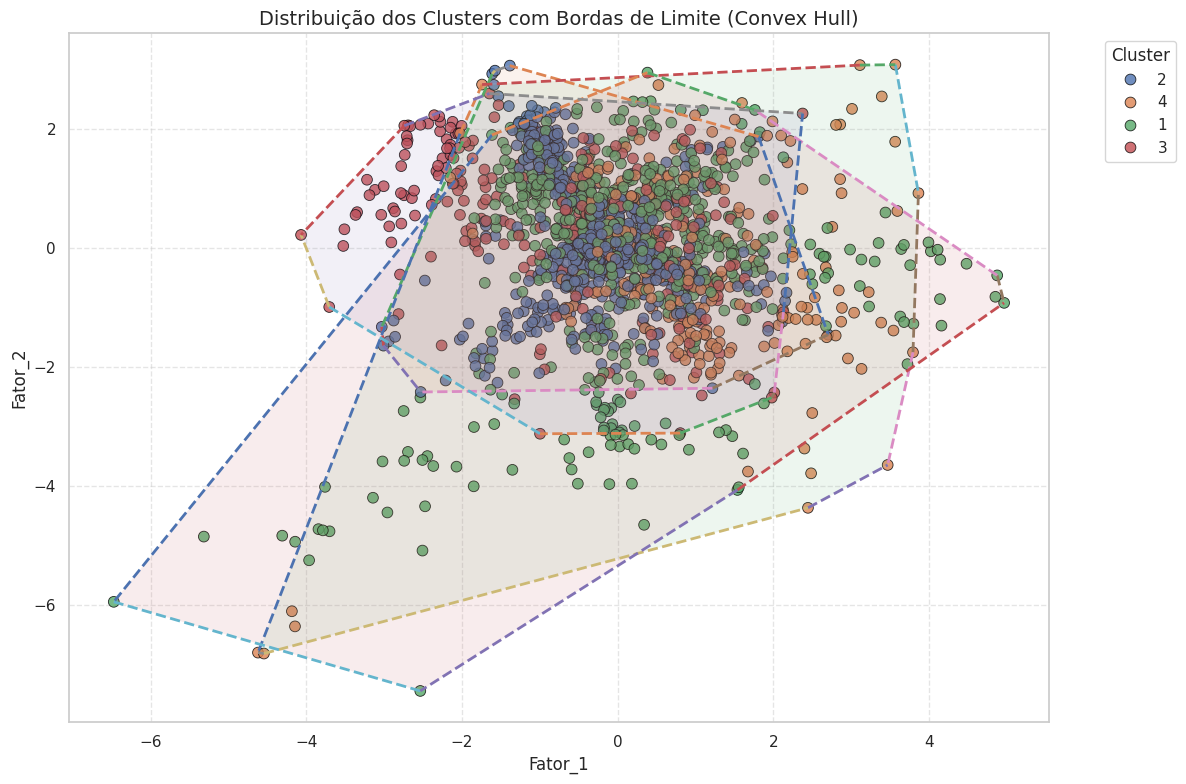

In [23]:
from scipy.spatial import ConvexHull
cores_padrao = {
    0: '#348ABD',
    1: "#E8AA40",
    2: "#76A02E",  # Verde
    3: '#E24A33',
    4: "#837AC0"   # Amarelo
}

# NOVA FUNÇÃO: Para desenhar os pontos e as bordas
def plotar_clusters_com_bordas(df):
    plt.figure(figsize=(12, 8))
    
    # 1. Plota os pontos normalmente (Scatterplot)
    sns.scatterplot(
        data=df, 
        x='Fator_1', 
        y='Fator_2', 
        hue='Cluster', 
        s=60, 
        alpha=0.8,
        edgecolor='black'
    )
    
    # 2. O Segredo: Desenha as bordas (Convex Hull) para cada cluster
    clusters_unicos = df['Cluster'].dropna().unique()
    
    for cluster in clusters_unicos:
        # Pega apenas as coordenadas X e Y do cluster atual
        pontos = df[df['Cluster'] == cluster][['Fator_1', 'Fator_2']].values
        
        # A matemática exige pelo menos 3 pontos para formar um polígono fechado
        if len(pontos) >= 3:
            hull = ConvexHull(pontos)
            
            # Desenha a linha da borda conectando os vértices extremos
            for simplex in hull.simplices:
                plt.plot(pontos[simplex, 0], pontos[simplex, 1], lw=2, linestyle='--')
            
            # Opcional: Preenche o interior do cluster com uma cor super transparente
            plt.fill(pontos[hull.vertices, 0], pontos[hull.vertices, 1], alpha=0.1)

    plt.title('Distribuição dos Clusters com Bordas de Limite (Convex Hull)', fontsize=14)
    plt.xlabel('Fator_1', fontsize=12)
    plt.ylabel('Fator_2', fontsize=12)
    plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

plotar_clusters_com_bordas(coordenadas_clusters_fixos)

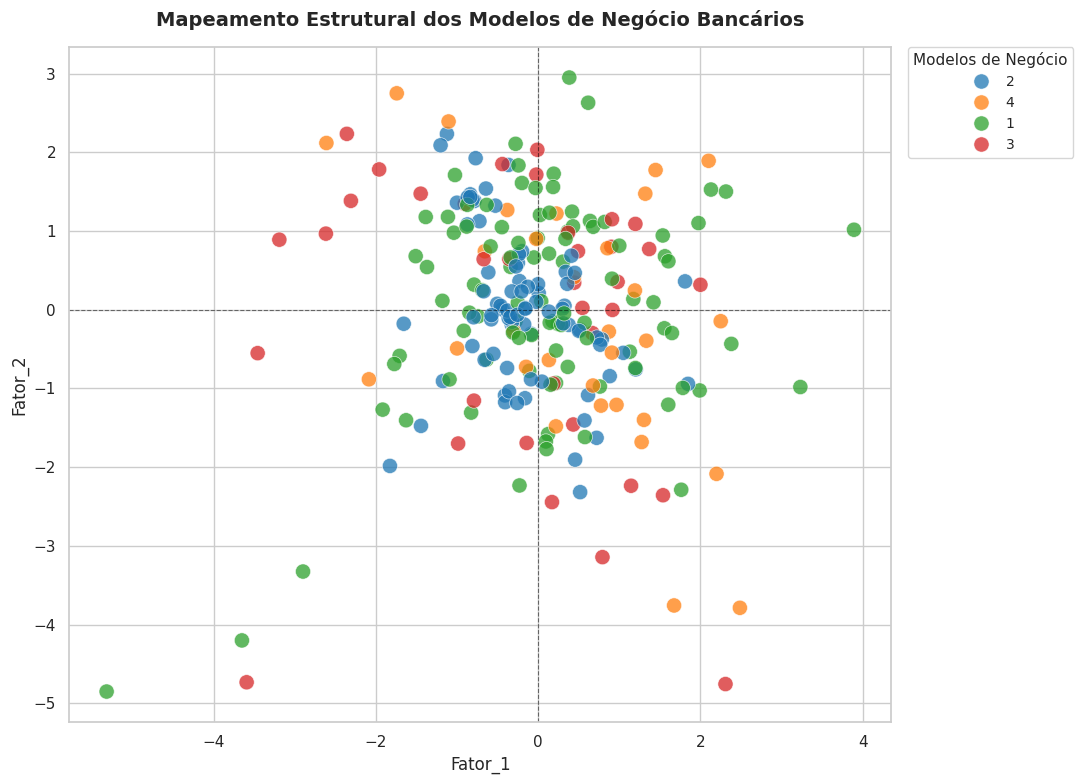

In [24]:
def clusters_ano(coordenadas, ano):
    coordenadas_ano = coordenadas[coordenadas['ano'] == ano]
    plotar_clusters(coordenadas_ano)

clusters_ano(coordenadas, ano= 2024)

In [25]:
'''coordenadas_clusters_fixos =  coordenadas.copy(deep=True)
coordenadas_clusters_fixos['Cluster'] = coordenadas_clusters_fixos.groupby('cnpj')['Cluster'].transform(lambda x: x.mode()[0])

plotar_clusters(coordenadas_clusters_fixos)'''

"coordenadas_clusters_fixos =  coordenadas.copy(deep=True)\ncoordenadas_clusters_fixos['Cluster'] = coordenadas_clusters_fixos.groupby('cnpj')['Cluster'].transform(lambda x: x.mode()[0])\n\nplotar_clusters(coordenadas_clusters_fixos)"

In [26]:
def bancos_cluster(df_filtrado_clusters_fixos, cluster):
    df_cluster1 = df_filtrado_clusters_fixos[df_filtrado_clusters_fixos['Cluster'] == cluster]

    lista_bancos = df_cluster1[['cnpj', 'nome']].drop_duplicates()

    lista_bancos = lista_bancos.sort_values(by='nome')

    print(f"Total de bancos únicos no Cluster {cluster}: {len(lista_bancos)}")
    #print(lista_bancos.head(20))
    return lista_bancos

bancos_c1 = bancos_cluster(df_filtrado_clusters_fixos, 1)
bancos_c2 = bancos_cluster(df_filtrado_clusters_fixos, 2)
bancos_c3 = bancos_cluster(df_filtrado_clusters_fixos, 3)
bancos_c4 = bancos_cluster(df_filtrado_clusters_fixos, 4)

Total de bancos únicos no Cluster 1: 95
Total de bancos únicos no Cluster 2: 84
Total de bancos únicos no Cluster 3: 45
Total de bancos únicos no Cluster 4: 29


In [27]:
loadings_high = loadings[loadings.abs().gt(0.3).any(axis=1)]
loadings_fator1 = loadings['Fator_1']
loadings_fator1 = loadings_fator1[loadings_fator1.abs().gt(0.2)]
loadings_fator2 = loadings['Fator_2']
loadings_fator2 = loadings_fator2[loadings_fator2.abs().gt(0.2)]
loadings_fator3 = loadings['Fator_3']
loadings_fator3 = loadings_fator3[loadings_fator3.abs().gt(0.2)]

In [28]:
centroids = resultado_final['centroid'].T

In [35]:
print(resultado_final['centroid'])

[[ 0.107074   -0.09340068 -0.2336561 ]
 [-0.21736993  0.19930325 -0.162539  ]
 [-0.33670467 -0.01928841  1.06214517]
 [ 0.70443857 -0.2652351  -0.12796662]]


In [40]:
loadings.to_clipboard(index= True)

OSError: [Errno 8] Exec format error: 'clip.exe'

In [41]:
import scipy.stats as stats

def teste_t_mannwhitney_clusters(df_prov, c1, c2, conta):

    # Separar as amostras dos dois clusters
    grupo_c0 = df_prov[df_prov['Cluster'] == c1][conta].dropna()
    grupo_c2 = df_prov[df_prov['Cluster'] == c2][conta].dropna()

    print(f"Tamanho da Amostra C0: {grupo_c0.count()} | Média: {grupo_c0.mean():.4f}")
    print(f"Tamanho da Amostra C2: {grupo_c2.count()} | Média: {grupo_c2.mean():.4f}\n")

    # Teste T de Welch (Hipótese Alternativa: C2 é MAIOR que C0)
    t_stat, p_val_t = stats.ttest_ind(grupo_c2, grupo_c0, equal_var=False, alternative='greater')

    print("=== Teste T de Welch (Paramétrico) ===")
    print(f"Estatística T: {t_stat:.4f}")
    print(f"P-valor:       {p_val_t:.4e}")
    if p_val_t < 0.05:
        print(f"Conclusão: Rejeitamos H0. A proporção de crédito no Cluster {c2} é ESTATISTICAMENTE MAIOR que no Cluster {c1}.\n")
    else:
        print(f"Conclusão: Não podemos afirmar que o Cluster {c2} é maior.\n")

    # Teste de Mann-Whitney (Não-Paramétrico)
    u_stat, p_val_u = stats.mannwhitneyu(grupo_c2, grupo_c0, alternative='greater')

    print("=== Teste U de Mann-Whitney (Não-Paramétrico) ===")
    print(f"Estatística U: {u_stat:.4f}")
    print(f"P-valor:       {p_val_u:.4e}")
    if p_val_u < 0.05:
        print(f"Conclusão: Rejeitamos H0. A mediana da conta no Cluster {c2} é ESTATISTICAMENTE MAIOR que no Cluster {c1}.")
    else:
        print(f"Conclusão: Não podemos afirmar que a mediana de {c2} é maior.")

def plotar_distribuicao_por_cluster(df_prov, c1, c2, conta):
    df_plot = df_prov[df_prov['Cluster'].isin([c1, c2])].copy()

    df_plot['Cluster'] = df_plot['Cluster'].astype(str)

    # Configurar o estilo visual acadêmico do gráfico
    sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)

    # ==========================================
    # GRÁFICO 1: Histograma + Curva de Densidade (KDE)
    # ==========================================
    plt.figure(figsize=(10, 6))
    sns.histplot(
        data=df_plot, 
        x=conta, 
        hue='Cluster',
        hue_order=[str(c1), str(c2)],
        kde=True,               # Adiciona a linha suave (KDE) para ver a normalidade
        stat='density',         # Normaliza o eixo Y para comparar grupos de tamanhos diferentes
        common_norm=False,      # Calcula a densidade separadamente para C0 e C2
        palette=['#1f77b4', '#d62728'], # Cores clássicas (Azul e Vermelho)
        alpha=0.4,              # Transparência
        bins=30                 # Quantidade de barras
    )

    plt.title(f'Distribuição {conta} (Cluster {c1} vs {c2})', fontsize=14, weight='bold')
    plt.xlabel(f'{conta}', fontsize=12)
    plt.ylabel('Densidade', fontsize=12)

    plt.tight_layout()
    plt.show()

def comparar_clusters(banks, c1, c2, conta):
    df_prov = banks.copy()
    df_prov[conta] = np.log(df_prov[conta].abs() + 1e-6)

    teste_t_mannwhitney_clusters(df_prov, c1, c2, conta)
    plotar_distribuicao_por_cluster(df_prov, c1, c2, conta)


In [42]:
df_inicial_sociedades = df_inicial[df_inicial['taxonomia'].str.startswith('soc')]

In [43]:
#comparar_clusters(model_lerner, c1=3, c2=2, conta='Lerner')


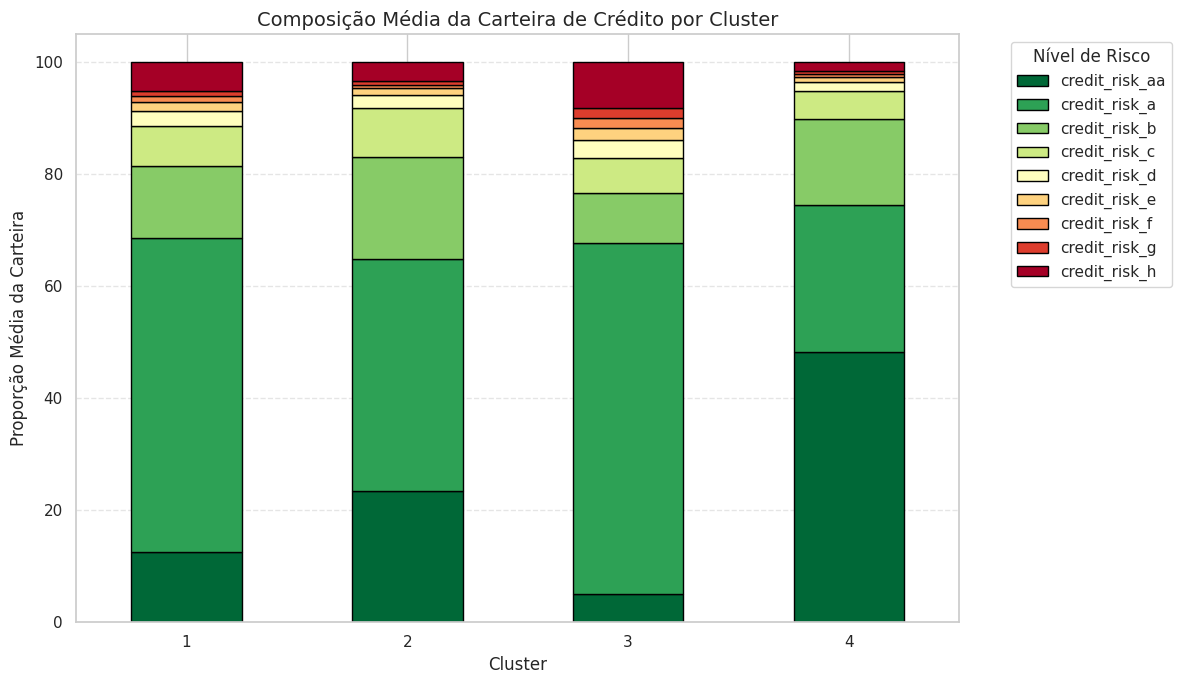

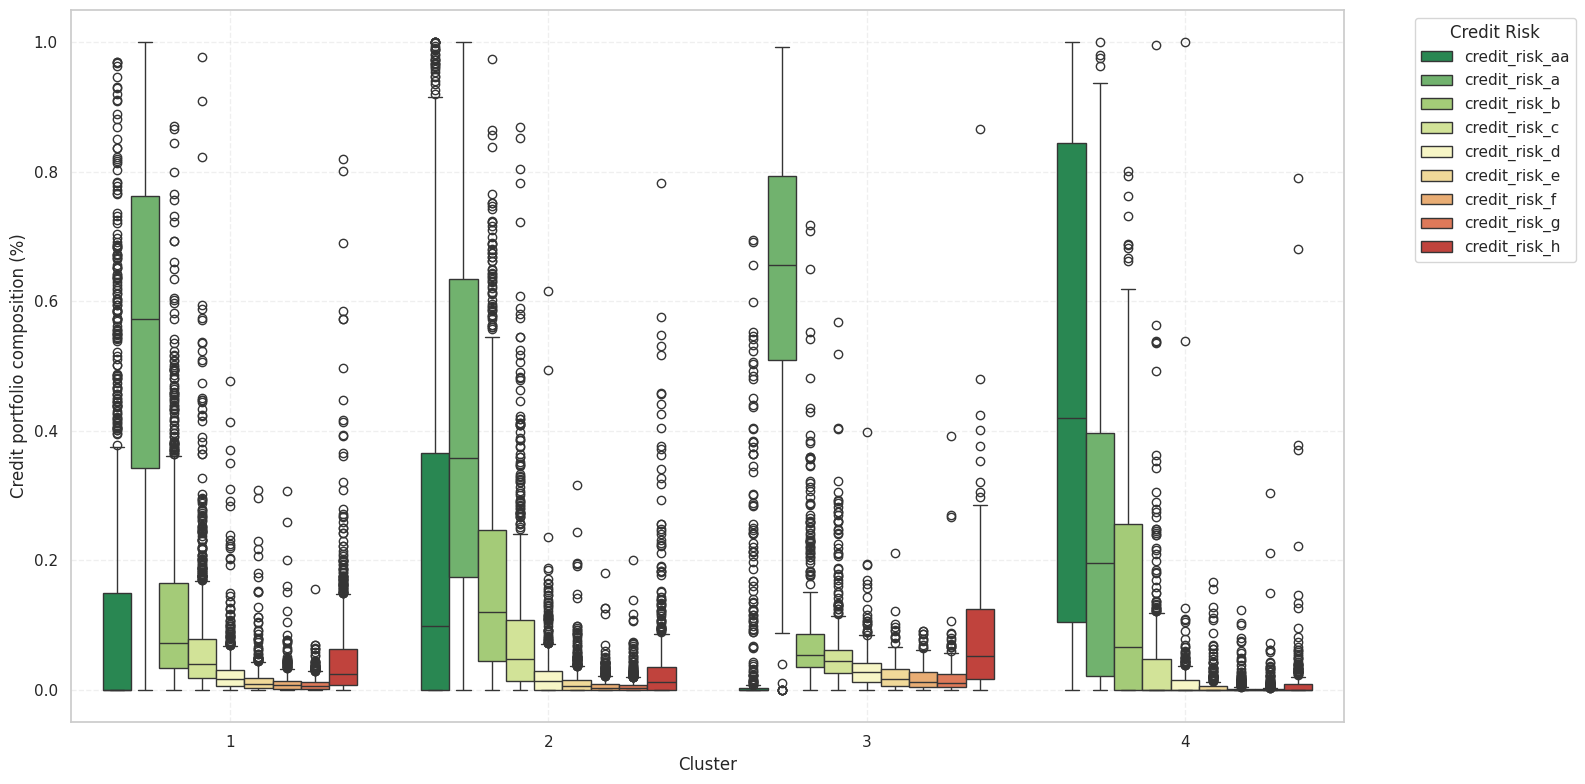

In [44]:
def criar_tabela_operacoes_credito(df_original, df):
    operacoes_de_credito = df_original[['ano', 'cnpj', 'nome', 'taxonomia', 'Cluster', 'compensacao ativa - classificacao da carteira de creditos', 'compensacao ativa - total geral do ativo']].copy()
    niveis = ['aa', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h']
    colunas_risco_df = [f'compensacao ativa - operacoes de risco nivel {letra}' for letra in niveis]

    df_busca = df[['ano', 'cnpj'] + colunas_risco_df].drop_duplicates(subset=['ano', 'cnpj'])

    operacoes_de_credito = pd.merge(operacoes_de_credito, df_busca, on=['ano', 'cnpj'], how='left')

    colunas_novas = []

    for letra in niveis:
        coluna_risco = f'compensacao ativa - operacoes de risco nivel {letra}'
        nome_nova_coluna = f'credit_risk_{letra}'
        colunas_novas.append(nome_nova_coluna)

        operacoes_de_credito[nome_nova_coluna] = ((operacoes_de_credito['compensacao ativa - total geral do ativo'] * operacoes_de_credito[coluna_risco])/operacoes_de_credito['compensacao ativa - classificacao da carteira de creditos'].replace(0, np.nan)).fillna(0)
        operacoes_de_credito.drop(columns=[coluna_risco], inplace=True)

    operacoes_de_credito['risco_total'] = operacoes_de_credito[colunas_novas].sum(axis=1)


    clusters_unicos = operacoes_de_credito['Cluster'].dropna().unique()
    
    #print("Contagem de Zeros nas Contas de Risco:")
    for cluster in sorted(clusters_unicos):
        # Filtra a tabela apenas para o cluster da vez
        df_filtrado = operacoes_de_credito[operacoes_de_credito['Cluster'] == cluster]
        
        # Conta os zeros APENAS nas colunas de risco (usando a lista salva no passo 2)
        zeros_por_nivel = (df_filtrado[colunas_novas] == 0).sum()
        
        #print(f"\n--- Cluster {cluster} ---")
        #print(zeros_por_nivel)
    
    linhas_todas_zero = (operacoes_de_credito[colunas_novas] == 0).all(axis=1)

    zeros_absolutos_por_cluster = linhas_todas_zero.groupby(operacoes_de_credito['Cluster']).sum()

    #print("\nQuantidade de instituições com ZERO em TODAS as faixas de risco (por Cluster):")
    #print(zeros_absolutos_por_cluster)

    # Criando gráfico de barras para visualizar a distribuição dos riscos por cluster
    colunas_risco = [col for col in operacoes_de_credito.columns if 'credit_risk_' in col]

    perfil_risco_cluster = operacoes_de_credito.groupby('Cluster')[colunas_risco].mean()
    
    #perfil_risco_cluster.drop(columns=['credit_risk_a'], inplace=True) # Risco AA é tão alto que distorce a visualização, então removemos
    perfil_risco_100 = perfil_risco_cluster.div(perfil_risco_cluster.sum(axis=1), axis=0) * 100

    # O colormap 'RdYlGn_r' vai do Verde (risco baixo) ao Vermelho (risco alto)
    perfil_risco_100.plot(kind='bar', stacked=True, figsize=(12, 7), colormap='RdYlGn_r', edgecolor='black')

    plt.title('Composição Média da Carteira de Crédito por Cluster', fontsize=14)
    plt.ylabel('Proporção Média da Carteira', fontsize=12)
    plt.xlabel('Cluster', fontsize=12)

    # Ajuste da legenda
    plt.legend(title='Nível de Risco', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.xticks(rotation=0) # Mantém os números dos clusters retos
    plt.tight_layout()
    plt.show()

    # Criando uma visualização de boxplot

    df_melted = operacoes_de_credito.melt(
        id_vars=['Cluster'], 
        value_vars=colunas_risco,
        var_name='Nível de Risco', 
        value_name='Credit portfolio composition (%)'
    )

    plt.figure(figsize=(16, 8))
    sns.boxplot(
        data=df_melted, 
        x='Cluster', 
        y='Credit portfolio composition (%)', 
        hue='Nível de Risco',
        palette='RdYlGn_r'
    )

    #plt.title('Distribution of Credit Risk by Cluster', fontsize=14)
    plt.legend(title='Credit Risk', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.show()
    return operacoes_de_credito

perfil_credito = criar_tabela_operacoes_credito(df_inicial, df_filtrado_completo)  

In [45]:
def criar_tabela_balanço(df_original):
    # 1. Defina as 5 variáveis (contas) que você quer analisar
    # Substitua pelos nomes exatos das colunas no seu DataFrame
    contas_escolhidas = ['ativo realizavel - disponibilidades', 'ativo realizavel - aplicacoes interfinanceiras de liquidez', 'ativo realizavel - titulos e valores mobiliarios e instrumentos financeiros derivativos', 'ativo realizavel - relacoes interfinanceiras', 'ativo realizavel - relacoes interdependencias', 'ativo realizavel - operacoes de credito', 'ativo realizavel - operacoes de arrendamento mercantil', 'ativo permanente - ativo permanente']
    #contas_escolhidas = ['resultado credor - rendas de operacoes de credito', 'resultado devedor - (-) aprovisionamentos e ajustes patrimoniais', 'resultado devedor - (-) despesas administrativas', 'compensacao ativa - operacoes de risco nivel h', 'ativo realizavel - (-) provisoes para operacoes de credito']

    # 2. Agrupe os dados pelo Cluster e calcule a Mediana dessas 5 contas
    # Usamos a mediana para evitar que outliers distorçam a barra
    df_agrupado = df_original.groupby('Cluster')[contas_escolhidas].median().abs()
    df_agrupado = df_agrupado.div(df_agrupado.sum(axis=1), axis=0)

    # 3. Gere o Gráfico de Barras Empilhadas
    # O parâmetro 'stacked=True' é o que faz a mágica de empilhar
    fig, ax = plt.subplots(figsize=(12, 7))
    df_agrupado.plot(kind='bar', stacked=True, ax=ax, colormap='Set2', edgecolor='black')

    # 4. Formatação para deixar com cara de apresentação executiva
    plt.title('Composição dos Clusters pelas 5 Contas Selecionadas', fontsize=16)
    plt.xlabel('Número do Cluster', fontsize=12)
    plt.ylabel('Valor Mediano (Proporção do Ativo Total)', fontsize=12)

    # Rotaciona os números do eixo X para ficarem retos
    plt.xticks(rotation=0) 

    # Move a legenda para fora do gráfico para não tampar as barras
    plt.legend(title='Contas Financeiras', bbox_to_anchor=(1.05, 1), loc='upper left')

    # Ajusta o layout para a legenda não ser cortada ao salvar
    plt.tight_layout() 

    plt.show()

#criar_tabela_balanço(df_filtrado_clusters_fixos)

In [46]:
def criar_tabela_operacoes_credito(df_original, df):
    operacoes_de_credito = df_original[['ano', 'cnpj', 'nome', 'taxonomia', 'Cluster', 'compensacao ativa - classificacao da carteira de creditos', 'compensacao ativa - total geral do ativo']].copy()
    niveis = ['aa', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h']
    colunas_risco_df = [f'compensacao ativa - operacoes de risco nivel {letra}' for letra in niveis]

    df_busca = df[['ano', 'cnpj'] + colunas_risco_df].drop_duplicates(subset=['ano', 'cnpj'])

    operacoes_de_credito = pd.merge(operacoes_de_credito, df_busca, on=['ano', 'cnpj'], how='left')

    colunas_novas = []

    for letra in niveis:
        coluna_risco = f'compensacao ativa - operacoes de risco nivel {letra}'
        nome_nova_coluna = f'credit_risk_{letra}'
        colunas_novas.append(nome_nova_coluna)

        operacoes_de_credito[nome_nova_coluna] = ((operacoes_de_credito['compensacao ativa - total geral do ativo'] * operacoes_de_credito[coluna_risco])/operacoes_de_credito['compensacao ativa - classificacao da carteira de creditos'].replace(0, np.nan)).fillna(0)
        operacoes_de_credito.drop(columns=[coluna_risco], inplace=True)

    operacoes_de_credito['risco_total'] = operacoes_de_credito[colunas_novas].sum(axis=1)


    clusters_unicos = operacoes_de_credito['Cluster'].dropna().unique()
    
    #print("Contagem de Zeros nas Contas de Risco:")
    for cluster in sorted(clusters_unicos):
        # Filtra a tabela apenas para o cluster da vez
        df_filtrado = operacoes_de_credito[operacoes_de_credito['Cluster'] == cluster]
        
        # Conta os zeros APENAS nas colunas de risco (usando a lista salva no passo 2)
        zeros_por_nivel = (df_filtrado[colunas_novas] == 0).sum()
        
        #print(f"\n--- Cluster {cluster} ---")
        #print(zeros_por_nivel)
    
    linhas_todas_zero = (operacoes_de_credito[colunas_novas] == 0).all(axis=1)

    zeros_absolutos_por_cluster = linhas_todas_zero.groupby(operacoes_de_credito['Cluster']).sum()

    #print("\nQuantidade de instituições com ZERO em TODAS as faixas de risco (por Cluster):")
    #print(zeros_absolutos_por_cluster)

    # Criando gráfico de barras para visualizar a distribuição dos riscos por cluster
    colunas_risco = [col for col in operacoes_de_credito.columns if 'credit_risk_' in col]

    perfil_risco_cluster = operacoes_de_credito.groupby('Cluster')[colunas_risco].mean()
    
    #perfil_risco_cluster.drop(columns=['credit_risk_a'], inplace=True) # Risco AA é tão alto que distorce a visualização, então removemos
    perfil_risco_100 = perfil_risco_cluster.div(perfil_risco_cluster.sum(axis=1), axis=0) * 100

    # O colormap 'RdYlGn_r' vai do Verde (risco baixo) ao Vermelho (risco alto)
    perfil_risco_100.plot(kind='bar', stacked=True, figsize=(12, 7), colormap='RdYlGn_r', edgecolor='black')

    plt.title('Composição Média da Carteira de Crédito por Cluster', fontsize=14)
    plt.ylabel('Proporção Média da Carteira', fontsize=12)
    plt.xlabel('Cluster', fontsize=12)

    # Ajuste da legenda
    plt.legend(title='Nível de Risco', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.xticks(rotation=0) # Mantém os números dos clusters retos
    plt.tight_layout()
    plt.show()

    # Criando uma visualização de boxplot

    df_melted = operacoes_de_credito.melt(
        id_vars=['Cluster'], 
        value_vars=colunas_risco,
        var_name='Nível de Risco', 
        value_name='Credit portfolio composition (%)'
    )

    plt.figure(figsize=(16, 8))
    sns.boxplot(
        data=df_melted, 
        x='Cluster', 
        y='Credit portfolio composition (%)', 
        hue='Nível de Risco',
        palette='RdYlGn_r'
    )

    #plt.title('Distribution of Credit Risk by Cluster', fontsize=14)
    plt.legend(title='Credit Risk', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.show()
    return operacoes_de_credito

#perfil_credito = criar_tabela_operacoes_credito(df_inicial, df)    



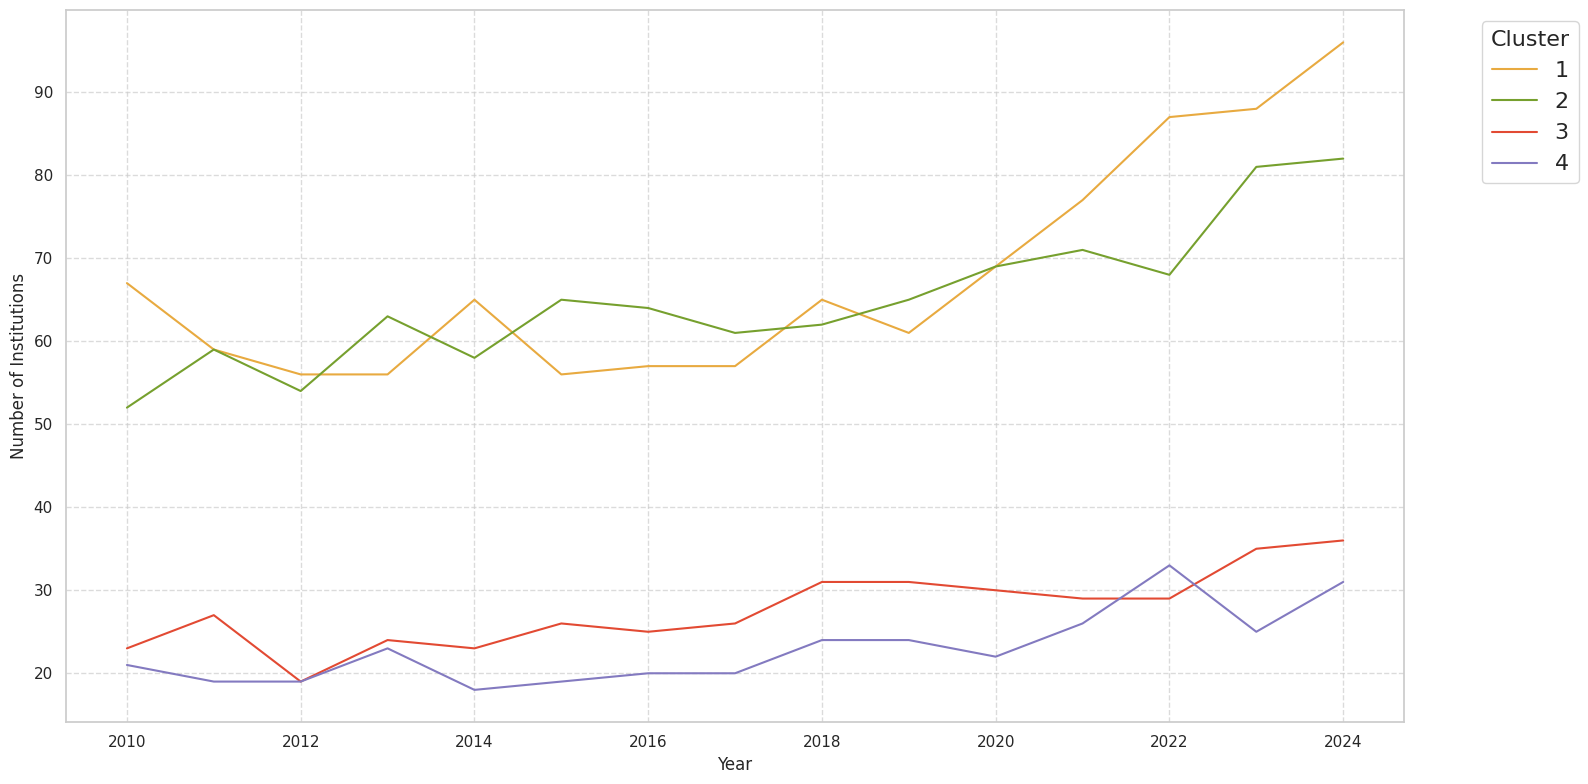

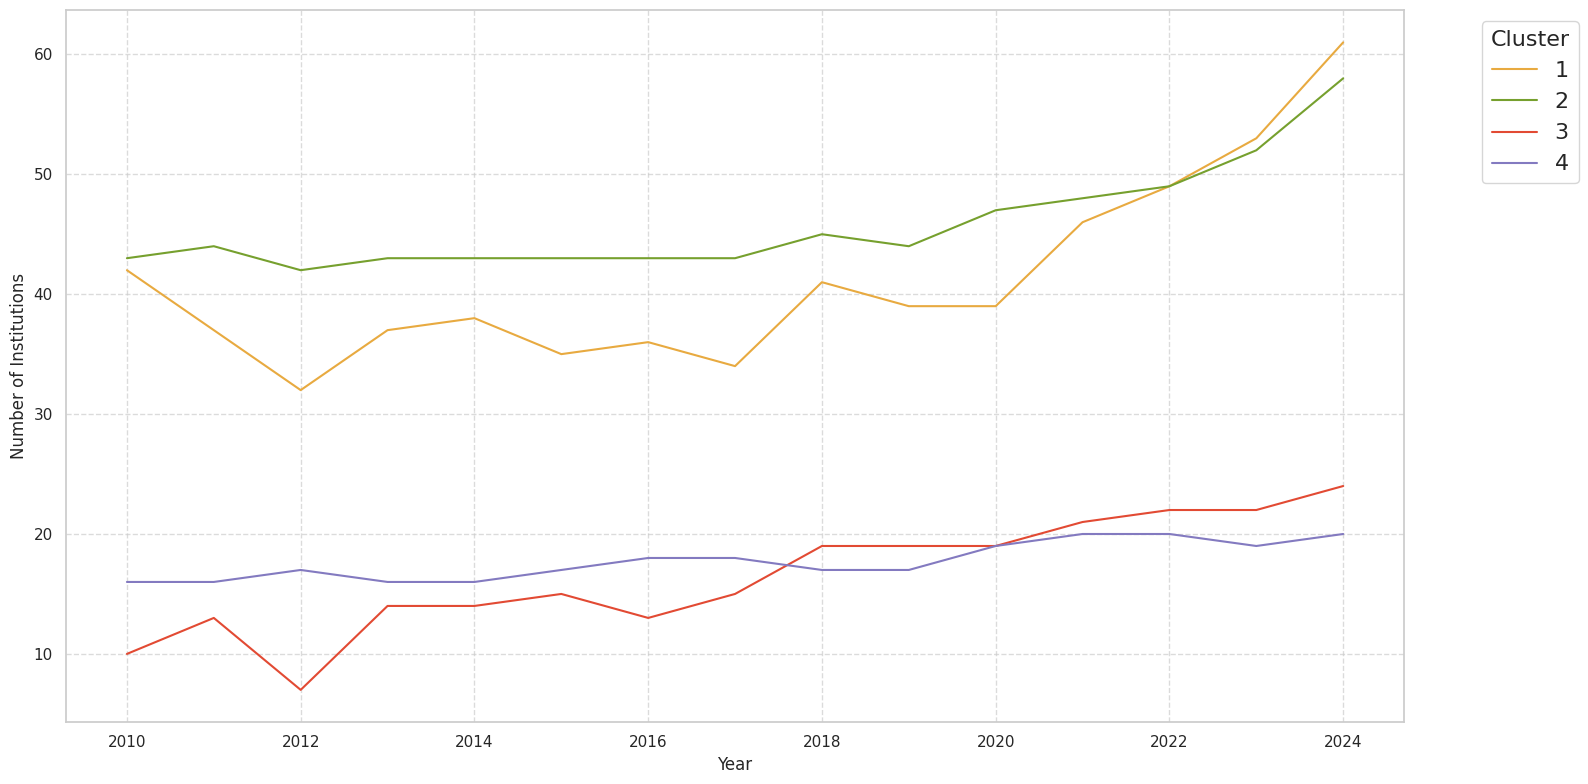

In [47]:
# Ver a evolução da quantidade de bancos em cada cluster por ano
def plotar_evolucao_clusters(df_filtrado):
    cores_padrao = {
        0: '#348ABD',
        1: "#E8AA40",
        2: "#76A02E",  # Verde
        3: '#E24A33',
        4: "#837AC0"   # Amarelo
    }

    evolucao_clusters = df_filtrado.groupby(['ano', 'Cluster']).size().unstack().fillna(0)
    evolucao_clusters.plot(kind='line', color=cores_padrao, stacked=False, marker='', alpha=1, figsize=(16,8))
    plt.ylabel('Number of Institutions', fontsize=12)
    plt.xlabel('Year', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left',fontsize=16, title_fontsize=16, markerscale=1.5)
    plt.tight_layout()
    plt.show()

plotar_evolucao_clusters(df_inicial)
plotar_evolucao_clusters(df_inicial_clusters_fixos)

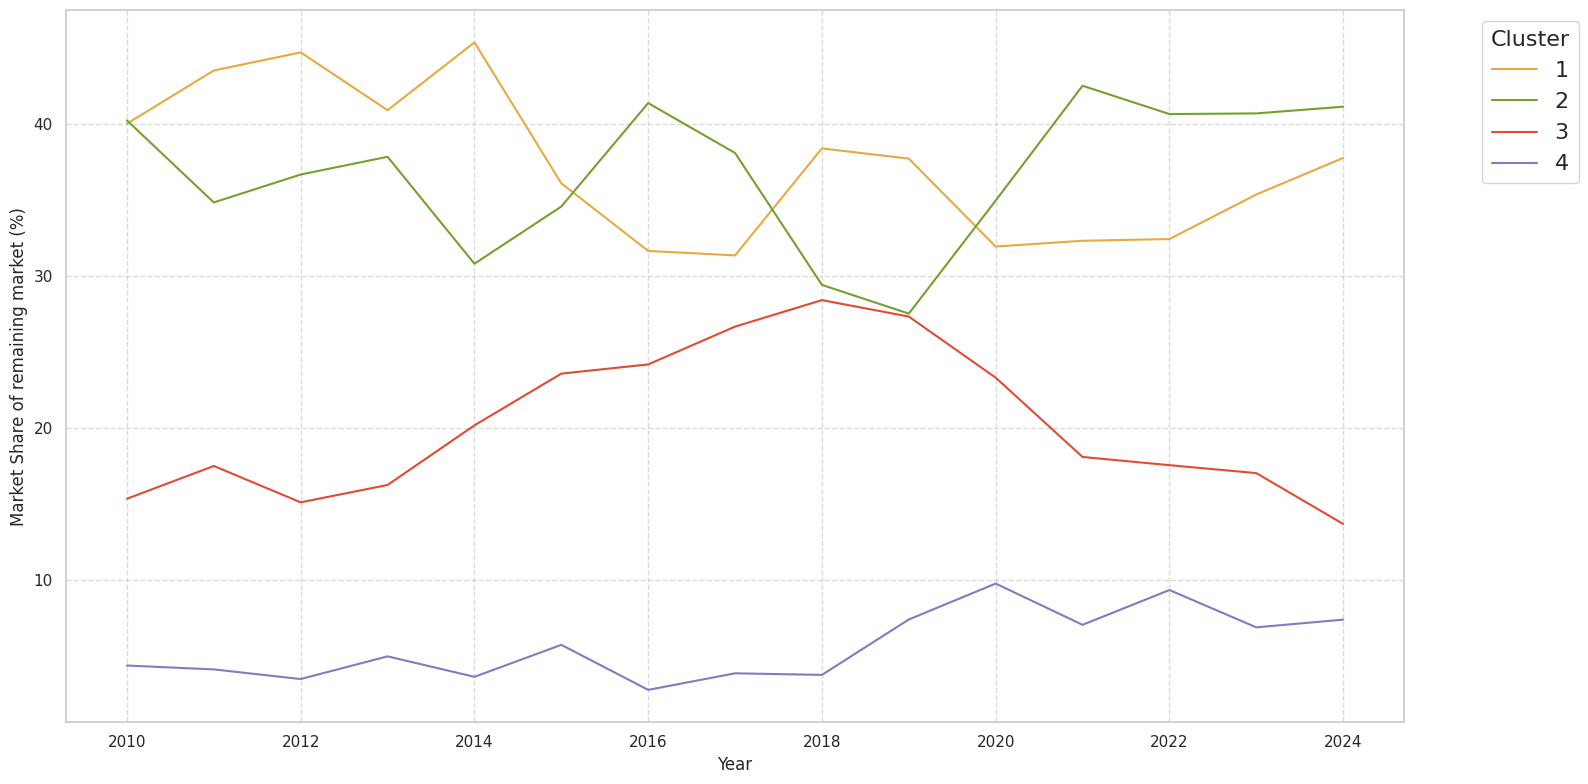

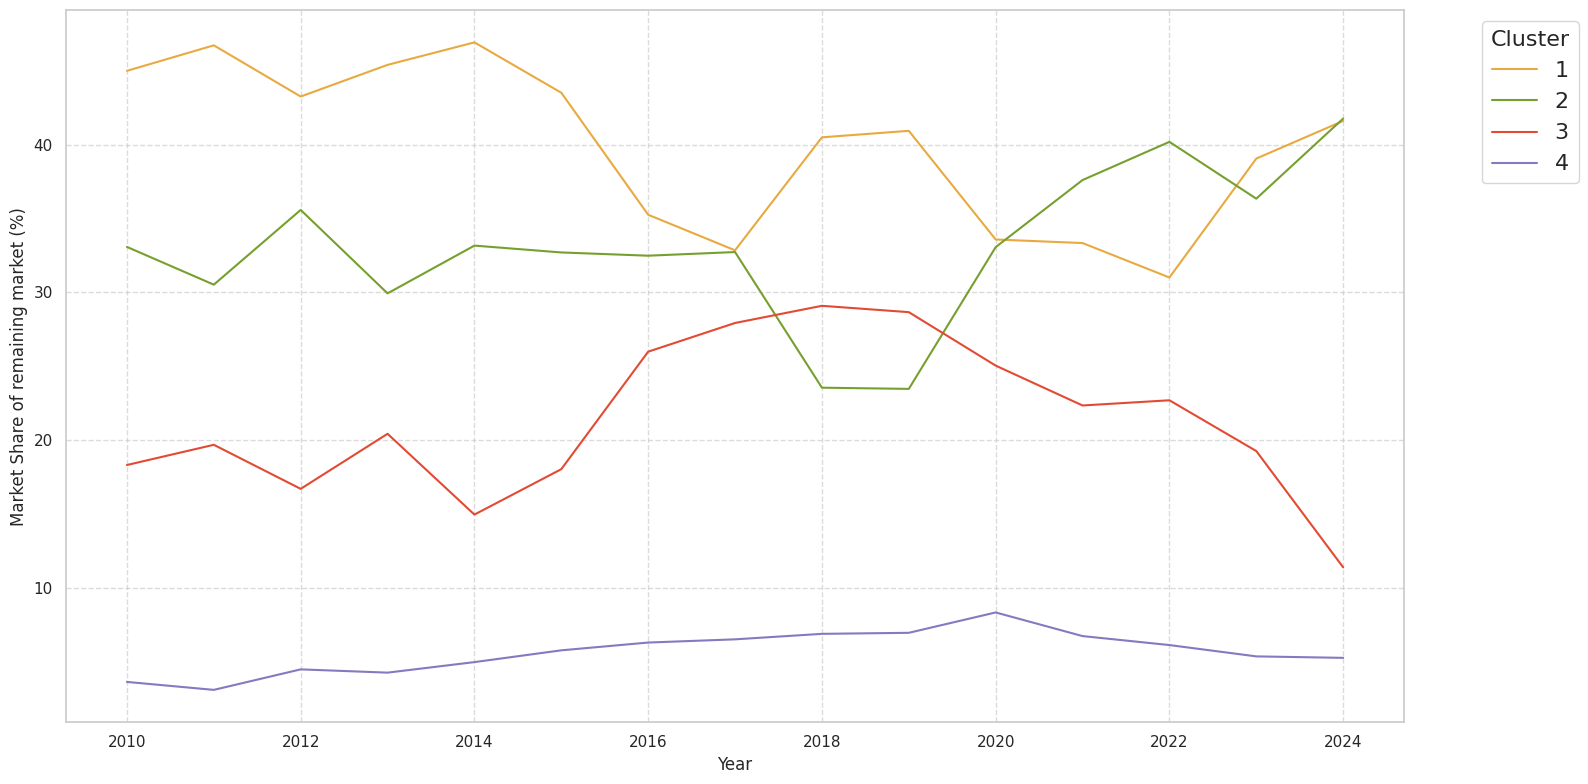

In [48]:
# Calculando o Market Share dos Clusters EXCLUINDO as 6 maiores instituições de cada ano

def calcular_market_share_clusters_excluindo_top5(df_original):
    # 1. Calcular o crédito individual de cada banco (CNPJ) em cada ano
    credito_individual = df_original.groupby(['ano', 'cnpj'])['ativo realizavel - operacoes de credito'].sum().reset_index()

    # 2. Encontrar os 6 maiores de cada ano
    # Ordenamos por ano (crescente) e crédito (decrescente), depois pegamos os 6 primeiros
    top6_por_ano = (credito_individual
                    .sort_values(by=['ano', 'ativo realizavel - operacoes de credito'], ascending=[True, False])
                    .groupby('ano')
                    .head(6)[['ano', 'cnpj']]) # Mantemos apenas as chaves de busca (ano e cnpj)

    # 3. Remover os Top 6 da base original
    # O indicator=True cria uma coluna '_merge' que diz se a linha estava nas duas tabelas ('both') ou só na original ('left_only')
    df_sem_top5 = pd.merge(df_original, top6_por_ano, on=['ano', 'cnpj'], how='left', indicator=True)

    # Filtramos para manter apenas os que NÃO estão no Top 6 e apagamos a coluna '_merge'
    df_sem_top5 = df_sem_top5[df_sem_top5['_merge'] == 'left_only'].drop(columns='_merge')

    # 1. Agrupar por ano e cluster usando a base sem os grandes bancos
    share_df = df_sem_top5.groupby(['ano', 'Cluster'])['ativo realizavel - operacoes de credito'].sum().reset_index()

    # Renomear para clareza
    share_df.columns = ['ano', 'Cluster', 'credito_cluster']

    # 2. Calcular o NOVO total do mercado para cada ano e fazer a divisão
    share_df['market_share'] = (
        share_df['credito_cluster'] / 
        share_df.groupby('ano')['credito_cluster'].transform('sum')
    )

    # Converter para porcentagem
    share_df['market_share_pct'] = share_df['market_share'] * 100

    # 3. Preparar a tabela matriz (Pivot)
    tabela_share = share_df.pivot(index='Cluster', columns='ano', values='market_share_pct').fillna(0)

    cores_padrao = {
        0: '#348ABD',
        1: "#E8AA40",
        2: "#76A02E",  # Verde
        3: '#E24A33',
        4: "#837AC0"   # Amarelo
    }

    tabela_share.T.plot(kind='line', color=cores_padrao, stacked=False, marker='', alpha=1, figsize=(16,8))

    plt.ylabel('Market Share of remaining market (%)', fontsize=12)
    plt.xlabel('Year', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left',fontsize=16, title_fontsize=16, markerscale=1.5)
    plt.tight_layout() # Evita que a legenda fique cortada ao salvar a imagem
    plt.show()

calcular_market_share_clusters_excluindo_top5(df_inicial)
calcular_market_share_clusters_excluindo_top5(df_inicial_clusters_fixos)

In [49]:
def bancos_sem_moda(coordenadas):
    # 1. Contar a quantidade de 'modas' (clusters mais frequentes) que cada banco tem
    # Se len() for maior que 1, significa que houve empate ou total indefinição
    contagem_modas = coordenadas.groupby('cnpj')['Cluster'].apply(lambda x: len(x.mode()))

    # 2. Filtrar os CNPJs que apresentam essa indefinição
    cnpjs_indefinidos = contagem_modas[contagem_modas > 1].index

    print(f"Alerta: Foram encontrados {len(cnpjs_indefinidos)} bancos com empate/indefinição de Cluster.")

    # 3. Criar uma tabela apenas com o histórico ano a ano desses bancos problemáticos
    historico_indefinidos = coordenadas[coordenadas['cnpj'].isin(cnpjs_indefinidos)].sort_values(by=['cnpj', 'ano'])

    # Visualizar o que aconteceu com eles ao longo do tempo
    display(historico_indefinidos[['cnpj', 'ano', 'Cluster']])
    return historico_indefinidos


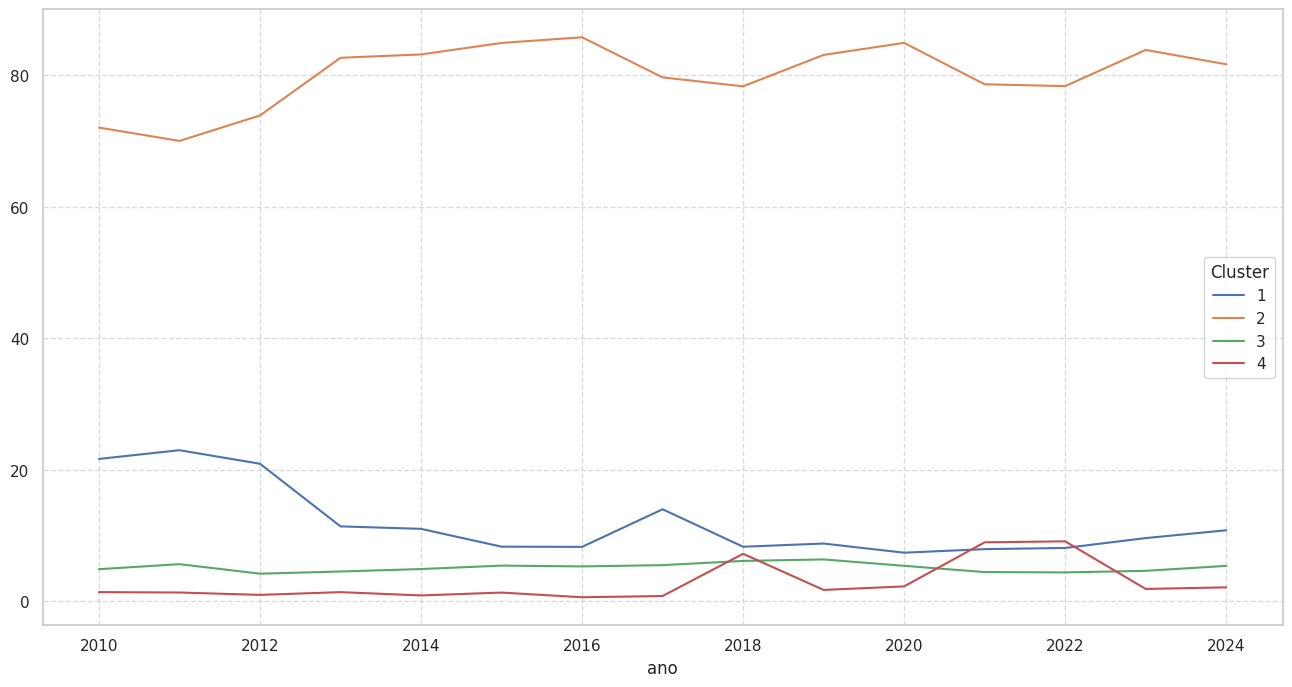

In [50]:
def calcular_market_share(df_original):
    share_individual = df_original.groupby(['ano', 'cnpj'])['ativo realizavel - operacoes de credito'].sum().reset_index()

    share_individual.columns = ['ano', 'cnpj', 'credito_cnpj']

    share_individual['market_share'] = (
        share_individual['credito_cnpj'] / 
        share_individual.groupby('ano')['credito_cnpj'].transform('sum')
    )

    share_individual = pd.merge(share_individual, df_original[['ano','cnpj', 'nome', 'taxonomia', 'Cluster']], on=['ano', 'cnpj'], how='left')

    coluna_c = share_individual.pop('market_share')
    share_individual.insert(6, 'market_share', coluna_c)
    coluna_c = share_individual.pop('credito_cnpj')
    share_individual.insert(6, 'credito_cnpj', coluna_c)

    # 1. Agrupar por ano e cluster para somar o crédito
    share_df = df_original.groupby(['ano', 'Cluster'])['ativo realizavel - operacoes de credito'].sum().reset_index()

    # Renomear para clareza
    share_df.columns = ['ano', 'Cluster', 'credito_cluster']

    # 2. Calcular o total do mercado para cada ano e dividir o valor do cluster por esse total
    share_df['market_share'] = (
        share_df['credito_cluster'] / 
        share_df.groupby('ano')['credito_cluster'].transform('sum')
    )

    # Converter para porcentagem para facilitar a leitura
    share_df['market_share_pct'] = share_df['market_share'] * 100

    tabela_share = share_df.pivot(index='Cluster', columns='ano', values='market_share_pct').fillna(0)

    tabela_share.T.plot(kind='line', stacked=False, marker='', alpha=1, figsize=(16,8))
    plt.grid(True, linestyle='--', alpha=0.7)
    return share_individual

share_individual = calcular_market_share(df_inicial)

Modelo econométrico

In [51]:
# Dados de volatilidade de taxas de juros

def dados_juros():
    conn = sqlite3.connect('dados/banking.db')

    query = """
    SELECT
        *
    FROM
        media_volatilidade_anual
    """

    taxas_termo = pd.read_sql_query(query, conn)

    conn.close()

    taxas_termo['ano'] = taxas_termo['ano'].astype(int)
    return taxas_termo

taxas_termo = dados_juros()

variaveis_df_original = pd.DataFrame({'Contas': [col for col in df_original.columns]})

In [52]:

def criar_indicadores_modelo(df_filtrado, df_inicial, share_individual, taxas_termo):
    model  = df_filtrado[['ano', 'cnpj', 'nome', 'taxonomia','Cluster']].copy()

    # Net Interest Margin (nim)

    #model['nim'] = 100 * (df[['resultado credor - receitas operacionais', 'resultado devedor - (-) despesas de captacao']].sum(axis=1) / df_inicial['ativo realizavel - ativo realizavel'])

    model['nim'] = 100 * (df_inicial['resultado credor - rendas de operacoes de credito'] + df_inicial['resultado credor - rendas com titulos e valores mobiliarios e instrumentos financeiros derivativos'] - df_inicial['resultado devedor - (-) despesas de captacao'].abs()) / df_inicial['ativo realizavel - ativo realizavel']

    # Herfindal (herf)

    share_individual['share_quadrado'] = share_individual['market_share'] ** 2
    hhi_anual = share_individual.groupby('ano')['share_quadrado'].sum().reset_index()
    hhi_anual.columns = ['ano', 'hhi']
    model = model.reset_index()

    model = pd.merge(
        model,
        hhi_anual,
        on=['ano'],
        how='left'
    )
    model = model.set_index('index')
    model.index.name = None
    model['hhi'] = model['hhi']

    # Operating Costs (aoc)

    model['aoc'] = 100 * (df_inicial['resultado devedor - (-) despesas operacionais'].abs() / df_inicial['compensacao ativa - total geral do ativo'])

    # Degree of risk aversion (riskaver)

    model['riskaver'] = 100 * (df_inicial['patrimonio liquido - patrimonio liquido'] / df_inicial['compensacao ativa - total geral do ativo'])

    # Volatility of market interest rates (sd*)

    model = model.reset_index()
    model = pd.merge(
        model,
        taxas_termo,
        on=['ano'],
        how='left'
    )
    model = model.set_index('index')
    model.index.name = None

    # Credit Risk (crerisk)

    model['crerisk'] = 100 * (df_inicial['ativo realizavel - (-) provisoes para operacoes de credito'].abs() / df_inicial['ativo realizavel - operacoes de credito'])

    # Interaction between credit risk and market risk (sd*crerisk)

    model['sd_3m*crerisk'] = model['sd_annual_3m'] * model['crerisk'] / 100
    model['sd_1ano*crerisk'] = model['sd_annual_1ano'] * model['crerisk'] / 100
    model['sd_2anos*crerisk'] = model['sd_annual_2anos'] * model['crerisk'] / 100
    model['sd_3anos*crerisk'] = model['sd_annual_3anos'] * model['crerisk'] / 100
    model['sd_5anos*crerisk'] = model['sd_annual_5anos'] * model['crerisk'] / 100

    # Average size of operations/volume of loans (size)

    model['size'] = np.log(df_inicial['ativo realizavel - operacoes de credito'])

    # Implicit interest payments (iip)

    model['iip'] = 100 * ((df_inicial['resultado devedor - (-) despesas operacionais'].abs() - df_inicial['resultado credor - rendas de prestacao de servicos']) / df_inicial['compensacao ativa - total geral do ativo'])

    # Opportunity costs of bank reserves (reser)

    model['reser'] = 100 * (df_inicial[['ativo realizavel - disponibilidades', 'ativo realizavel - aplicacoes interfinanceiras de liquidez']].sum(axis=1) / df_inicial['compensacao ativa - total geral do ativo'])

    #model['reser'] = 100 * ((df_inicial['ativo realizavel - disponibilidades'] + df_inicial['ativo realizavel - aplicacoes interfinanceiras de liquidez']) / df_inicial['compensacao ativa - total geral do ativo'])

    # Quality of management (ef)

    model['ef'] = 100 * (df_inicial['resultado devedor - (-) despesas operacionais'].abs() / df_inicial['resultado credor - receitas operacionais'])

    # Time dummies
    dummies_tempo = pd.get_dummies(model['ano'], drop_first=True)
    dummies_tempo = dummies_tempo.astype(int)
    model = pd.concat([model, dummies_tempo], axis=1)
    return model



model = criar_indicadores_modelo(df_filtrado_clusters_fixos, df_inicial, share_individual, taxas_termo)

In [53]:
# Market Structure (lerner)

import statsmodels.api as sm
from linearmodels.panel import PanelOLS, RandomEffects

def estimar_indice_lerner(model, df_inicial):
    model['Price'] = (df_inicial['resultado credor - receitas operacionais'] + df_inicial['resultado credor - receitas nao operacionais']) / df_inicial['compensacao ativa - total geral do ativo']

    model['C'] = df_inicial['resultado devedor - (-) despesas de captacao'] + df_inicial['resultado devedor - (-) despesas administrativas']

    model['ativo_total'] = df_inicial['compensacao ativa - total geral do ativo']

    model['w1'] = 100* df_inicial['resultado devedor - (-) despesas administrativas'] / df_inicial['compensacao ativa - total geral do ativo']

    model['w2'] = (df_inicial['resultado devedor - (-) despesas operacionais'] - df_inicial['resultado devedor - (-) despesas administrativas']) / (df_inicial['ativo permanente - ativo permanente'] - df_inicial['ativo permanente - ativos intangiveis'] - df_inicial['ativo permanente - investimentos'])

    model['w3'] = (df_inicial['resultado devedor - (-) despesas de captacao'] + df_inicial['resultado devedor - (-) despesas de obrigacoes por emprestimos e repasses'] + df_inicial['resultado devedor - (-) despesas com titulos e valores mobiliarios e instrumentos financeiros derivativos'] + df_inicial['resultado devedor - (-) aprovisionamentos e ajustes patrimoniais']) / df_inicial['passivo exigivel - depositos']

    # ========================================================
    # Normalização (Homogeneidade de Grau 1)
    # Dividimos C, w1 e w2 pelo w3
    # ========================================================
    model['C_norm']  = model['C'] / model['w3']
    model['w1_norm'] = model['w1'] / model['w3']
    model['w2_norm'] = model['w2'] / model['w3']

    # ========================================================
    # Transformações Logarítmicas e Termos Quadráticos (Translog)
    # ========================================================
    # Evitar log de zero (adicionando um valor minúsculo)
    epsilon = 1e-10

    model['ln_C']  = np.log(model['C_norm'] + epsilon)
    model['ln_TA'] = np.log(model['ativo_total'] + epsilon)
    model['ln_w1'] = np.log(model['w1_norm'] + epsilon)
    model['ln_w2'] = np.log(model['w2_norm'] + epsilon)

    # Quadrados (já multiplicados por 0.5 conforme a fórmula do artigo)
    model['ln_TA_sq'] = 0.5 * (model['ln_TA'] ** 2)
    model['ln_w1_sq'] = 0.5 * (model['ln_w1'] ** 2)
    model['ln_w2_sq'] = 0.5 * (model['ln_w2'] ** 2)

    # Interações
    model['ln_w1_w2'] = model['ln_w1'] * model['ln_w2']
    model['ln_TA_w1'] = model['ln_TA'] * model['ln_w1']
    model['ln_TA_w2'] = model['ln_TA'] * model['ln_w2']

    # Variável de Tendência Tecnológica (Trend)
    #model.set_index('ano', inplace=True)
    ano_minimo = model['ano'].min()
    model['Trend'] = model['ano'] - ano_minimo + 1
    model['Trend_sq'] = 0.5 * (model['Trend'] ** 2)
    model['Trend_ln_TA'] = model['Trend'] * model['ln_TA']

    # Limpar Nulos e Infinitos antes da regressão
    cols_reg = ['ln_C', 'ln_TA', 'ln_TA_sq', 'ln_w1', 'ln_w2', 'ln_w1_sq', 'ln_w2_sq', 'ln_w1_w2', 'ln_TA_w1', 'ln_TA_w2', 'Trend', 'Trend_sq', 'Trend_ln_TA']
    model = model.replace([np.inf, -np.inf], np.nan).dropna(subset=cols_reg)
    df_panel = model.set_index(['cnpj', 'ano'])

    # ========================================================
    # Regressão de Efeitos Fixos (Within-Group)
    # ========================================================
    X_cols = cols_reg[1:] # Todas as colunas exceto ln_C
    X = sm.add_constant(df_panel[X_cols])
    Y = df_panel['ln_C']

    # entity_effects=True garante que cada banco tenha seu intercepto próprio
    modelo = PanelOLS(Y, X, entity_effects=True)
    resultados = modelo.fit(cov_type='clustered', cluster_entity=True)
    print("=== Resultado da Função de Custo Translog ===")
    print(resultados.summary)

    # ========================================================
    # Calcular o Custo Marginal e o Índice de Lerner
    # ========================================================
    # Resgatando os coeficientes da regressão
    alpha_1 = resultados.params['ln_TA']
    alpha_2 = resultados.params['ln_TA_sq']
    gamma_1 = resultados.params['ln_TA_w1']
    gamma_2 = resultados.params['ln_TA_w2']
    mu_3    = resultados.params['Trend_ln_TA']

    # 1. Elasticidade do Custo em relação ao Ativo (d ln C / d ln TA)
    df_panel['elasticidade_custo'] = (alpha_1 + 
                                    alpha_2 * df_panel['ln_TA'] + 
                                    gamma_1 * df_panel['ln_w1'] + 
                                    gamma_2 * df_panel['ln_w2'] + 
                                    mu_3 * df_panel['Trend'])

    # 2. Custo Marginal (MC)
    df_panel['MC'] = (df_panel['C'] / df_panel['ativo_total']) * df_panel['elasticidade_custo']

    # 3. Preço do Produto (Receitas Totais / Ativo Total)
    #df_panel['Price'] = (df_panel['receitas_operacionais'] + df_panel['receitas_financeiras']) / df_panel['ativo_total']

    # 4. Índice de Lerner
    df_panel['Lerner'] = (df_panel['Price'] - df_panel['MC']) / df_panel['Price']
    df_panel.reset_index(inplace=True)
    
    return df_panel, resultados

#model_lerner, resultados_lerner = variaveis_lerner(model, df_inicial)
model_lerner, resultados_lerner = estimar_indice_lerner(model, df_inicial)

=== Resultado da Função de Custo Translog ===
                          PanelOLS Estimation Summary                           
Dep. Variable:                   ln_C   R-squared:                        0.9981
Estimator:                   PanelOLS   R-squared (Between):              0.9988
No. Observations:                1718   R-squared (Within):               0.9981
Date:                Fri, Jul 31 2026   R-squared (Overall):              0.9979
Time:                        17:52:43   Log-likelihood                   -436.01
Cov. Estimator:             Clustered                                           
                                        F-statistic:                   6.614e+04
Entities:                         188   P-value                           0.0000
Avg Obs:                       9.1383   Distribution:                 F(12,1518)
Min Obs:                       1.0000                                           
Max Obs:                       15.000   F-statistic (robust):  

In [54]:
import plotly.express as px

# Supondo que o seu dataframe final com os cálculos se chame 'df_com_lerner'
# E que ele tenha as colunas: 'Cluster', 'elasticidade_custo', 'Lerner', 'MC' (Custo Marginal) e 'Nome_Banco'
def plotar_bubble_chart(df_com_lerner, ano):
    df_plot = df_com_lerner[df_com_lerner['Cluster'] != 4]
    #df_plot = df_plot[df_plot['Cluster'] != 1]
    # 1. Preparar os dados (remover NAs para o gráfico não quebrar)
    if ano > 0:
        df_plot = df_plot[df_plot['ano'] == ano]
    
    df_plot = df_plot.dropna(subset=['elasticidade_custo', 'Lerner', 'MC']).copy()

    # Garantir que o Cluster seja tratado como categoria (texto) para cores distintas
    df_plot['Cluster'] = df_plot['Cluster'].astype(str)

    # 2. Criar o Gráfico de Dispersão de Bolhas (Bubble Chart)
    fig = px.scatter(
        df_plot,
        x="elasticidade_custo",         # Eixo X
        y="Lerner",                     # Eixo Y
        #size="ativo_total",                      # Tamanho da bolha (Pode trocar por 'ativo_total' se preferir)
        color="Cluster",                # Uma cor para cada modelo de negócios
        hover_name="nome",        # O nome que aparece em destaque ao passar o mouse
        hover_data={                    # Dados extras no tooltip
            "elasticidade_custo": ':.3f', 
            "Lerner": ':.3f',
            "MC": ':.4f',
            "Cluster": False            # Oculta o cluster do tooltip, pois já está na cor
        },
        opacity=0.6,                    # SOLUÇÃO 1: Transparência de 60%
        #size_max=18,                    # SOLUÇÃO 3: Reduzindo o limite de tamanho
        range_x=[0.75, 1.5],          # Limita o Eixo X (Elasticidade)
        range_y=[-0.25, 1.1],         # Limita o Eixo Y (Lerner). Coloquei 1.1 como teto lógico
        title="Microeconomia dos Clusters: Poder de Mercado vs. Economias de Escala",
        labels={
            "elasticidade_custo": "Elasticidade de Custo (Escala)",
            "Lerner": "Índice de Lerner (Poder de Precificação)",
            "MC": "Custo Marginal"
        },
        template="plotly_white"         # Fundo limpo e acadêmico
    )

    # 3. Adicionar as Linhas de Referência Estruturais (Cruciais para a análise)
    # Linha Vertical: Separa Economias de Escala (< 1) de Deseconomias (> 1)
    fig.add_vline(
        x=1.0, 
        line_dash="dash", 
        line_color="gray", 
        annotation_text="Retornos Constantes (E = 1)", 
        annotation_position="top right"
    )

    # Linha Horizontal: Separa Poder de Monopólio (> 0) de Preço Predatório (< 0)
    fig.add_hline(
        y=0.0, 
        line_dash="dash", 
        line_color="gray", 
        annotation_text="Concorrência Perfeita (L = 0)", 
        annotation_position="bottom right"
    )

    # 4. Centralizar o título e exibir
    fig.update_layout(title_x=0.5)
    fig.show()

    # Para salvar como uma página interativa separada (opcional):
    # fig.write_html("analise_clusters_microeconomia.html")

plotar_bubble_chart(model_lerner, ano=2015) # ano=0 para mostrar todos os anos juntos, ou coloque um ano específico

=== Correlação (Pearson) entre Poder de Mercado (Lerner) e Risco (crerisk) ===
 Cluster  Correlacao
       3    0.474688
       1    0.222274
       4    0.045323
       2   -0.130963

------------------------------------------------------------



/tmp/ipykernel_271347/2632967047.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  correlacoes = df_corr.groupby('Cluster').apply(
/home/hspassos/anaconda3/envs/bcb/lib/python3.12/site-packages/seaborn/regression.py:598: UserWarning: sharex is deprecated from the `lmplot` function signature. Please update your code to pass it using `facet_kws`.
  warnings.warn(msg, UserWarning)
/home/hspassos/anaconda3/envs/bcb/lib/python3.12/site-packages/seaborn/regression.py:598: UserWarning: sharey is deprecated from the `lmplot` function signature. Please update your code to pass it using `facet_kws`.
  warnings.warn(msg, UserWarning)


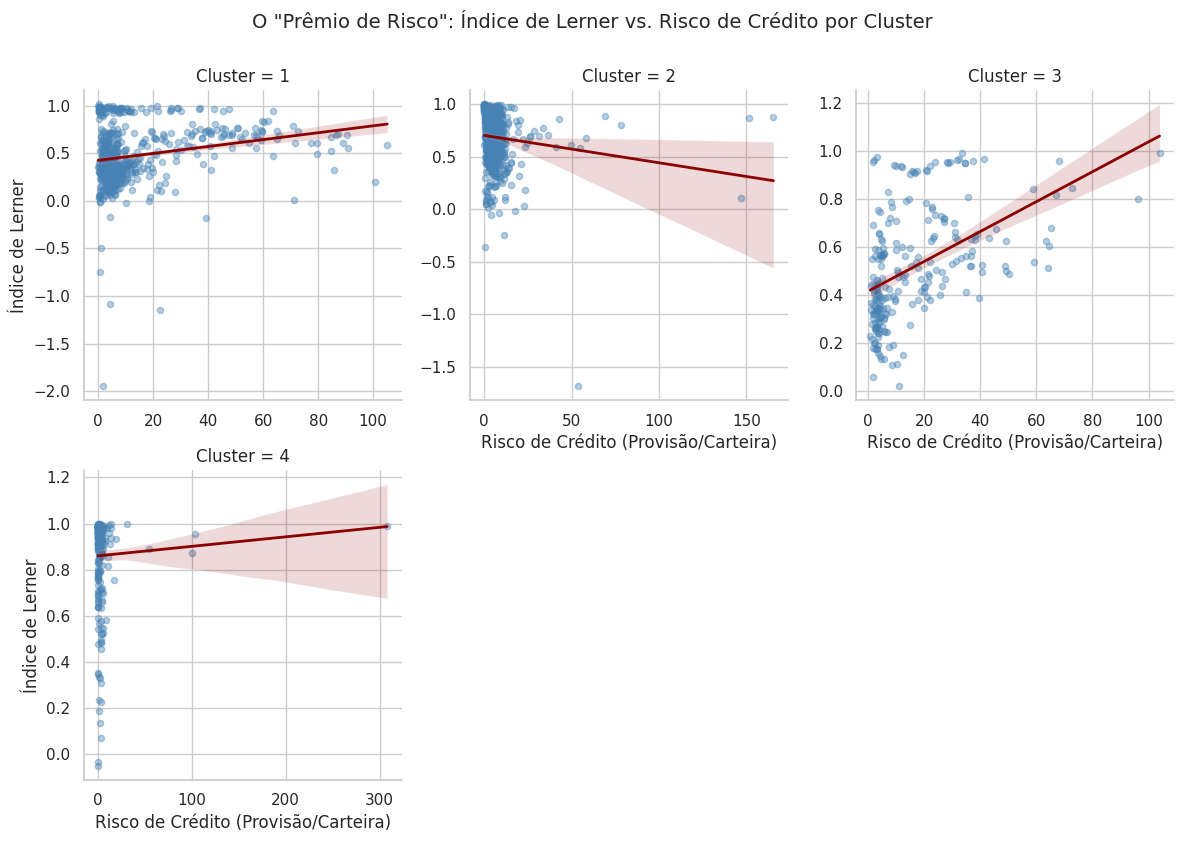

In [55]:

def analisar_correlacao_lerner_risco(model_lerner):
    df_corr = model_lerner.dropna(subset=['Lerner', 'crerisk', 'Cluster']).copy()

    # 2. A Tabela Matemática: Correlação de Pearson por Cluster
    print("=== Correlação (Pearson) entre Poder de Mercado (Lerner) e Risco (crerisk) ===")
    correlacoes = df_corr.groupby('Cluster').apply(
        lambda x: x['Lerner'].corr(x['crerisk'])
    ).reset_index(name='Correlacao')

    # Ordenar para ver quem tem a maior correlação
    correlacoes = correlacoes.sort_values(by='Correlacao', ascending=False)
    print(correlacoes.to_string(index=False))
    print("\n" + "-"*60 + "\n")

    # 3. A Prova Visual: Gráficos de Dispersão com Linha de Tendência
    # Configura o estilo acadêmico
    sns.set_theme(style="whitegrid")

    # Cria um painel com um gráfico para cada cluster
    g = sns.lmplot(
        data=df_corr,
        x='crerisk',                 # Eixo X: Risco de Crédito (Custo do Calote)
        y='Lerner',                  # Eixo Y: Índice de Lerner (Margem Bruta)
        col='Cluster',               # Divide em painéis por Cluster
        col_wrap=3,                  # Quantos gráficos por linha
        height=4,
        sharex=False,                # Deixa o eixo X livre (riscos variam muito)
        sharey=False,                # Deixa o eixo Y livre
        scatter_kws={'alpha': 0.4, 'color': 'steelblue', 's': 20}, # Bolhas transparentes
        line_kws={'color': 'darkred', 'linewidth': 2}              # Linha de tendência vermelha
    )

    # Ajuste do título principal
    g.fig.suptitle('O "Prêmio de Risco": Índice de Lerner vs. Risco de Crédito por Cluster', y=1.05, fontsize=14)
    g.set_axis_labels("Risco de Crédito (Provisão/Carteira)", "Índice de Lerner")

    plt.show()

analisar_correlacao_lerner_risco(model_lerner)

In [56]:

def rodar_regressao_margem_final(df):
    #df = df[df['ano'] <= 2018]
    df = df.set_index(['cnpj', 'ano'])
    # Transformar a coluna de clusters em Variáveis Dummy (0 ou 1)
    dummies_cluster = pd.get_dummies(df['Cluster'], prefix='Cluster', dtype=int)

    # Juntamos essas dummies de volta ao nosso painel principal
    df = pd.concat([df, dummies_cluster], axis=1)

    # 1. Preparar o DataFrame e limpar NAs nas variáveis do modelo
    # df já deve estar com multi-index ['cnpj', 'ano']
    vars_modelo = ['nim', 'Lerner', 'aoc', 'riskaver', 'crerisk', 'sd_annual_3m', 'ef', 'size', 'iip', 'reser']
    vars_clusters = ['Cluster_1', 'Cluster_3', 'Cluster_4'] # Base: Cluster 1

    #df = df.loc[:, ~df.columns.duplicated()].copy()
    # Adicionando as interações (Lerner x Cluster)
    for c in vars_clusters:
        df[f'Lerner_x_{c}'] = df['Lerner'] * df[c]
        
    vars_interacao = [f'Lerner_x_{c}' for c in vars_clusters]
    
    # Limpeza rigorosa
    cols_necessarias = vars_modelo + vars_clusters + vars_interacao
    df_reg = df.dropna(subset=cols_necessarias).copy()
    
    # 2. Separar Y e X
    Y = df_reg['nim']
    
    # Incluindo todas as variáveis independentes
    X = df_reg[['Lerner', 'aoc', 'riskaver', 'crerisk', 'sd_annual_3m', 'sd_annual_1ano', 'ef', 'size', 'iip', 'reser'] + vars_clusters]
    
    # Adiciona a constante (Intercepto)
    X = sm.add_constant(X)
    
    # 3. Estimar o Modelo com Efeitos Fixos
    # entity_effects=True: Efeitos fixos para cada banco
    # time_effects=True: Efeitos fixos para cada ano (absorve a macroeconomia geral)
    modelo_final = PanelOLS(Y, X, entity_effects=True, time_effects=True, drop_absorbed=True)
    
    # cov_type='clustered' com cluster_entity=True é o equivalente ao HC1/Erros Robustos
    # agrupados por banco, corrigindo heterocedasticidade e autocorrelação
    resultados_finais = modelo_final.fit(cov_type='clustered', cluster_entity=True)
    
    print("=== Determinantes da Margem de Juros (NIM) ===")
    print(resultados_finais.summary)
    
    return resultados_finais

resultados_nim = rodar_regressao_margem_final(model_lerner)

=== Determinantes da Margem de Juros (NIM) ===
                          PanelOLS Estimation Summary                           
Dep. Variable:                    nim   R-squared:                        0.7456
Estimator:                   PanelOLS   R-squared (Between):              0.0198
No. Observations:                1718   R-squared (Within):               0.7464
Date:                Fri, Jul 31 2026   R-squared (Overall):              0.5482
Time:                        17:52:44   Log-likelihood                   -5600.9
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      552.36
Entities:                         188   P-value                           0.0000
Avg Obs:                       9.1383   Distribution:                  F(8,1508)
Min Obs:                       1.0000                                           
Max Obs:                       15.000   F-statistic (robust): 

/tmp/ipykernel_271347/7231453.py:42: AbsorbingEffectWarning: 
Variables have been fully absorbed and have removed from the regression:

sd_annual_3m, sd_annual_1ano, Cluster_1, Cluster_3, Cluster_4

  resultados_finais = modelo_final.fit(cov_type='clustered', cluster_entity=True)


In [57]:
def rodar_regressao_efeitos_aleatorios(df):
    df = df.set_index(['cnpj', 'ano'])
    # Transformar a coluna de clusters em Variáveis Dummy (0 ou 1)
    dummies_cluster = pd.get_dummies(df['Cluster'], prefix='Cluster', dtype=int)

    # Juntamos essas dummies de volta ao nosso painel principal
    df = pd.concat([df, dummies_cluster], axis=1)
    
    # 2. Variáveis do modelo (Atenção ao nome da variável da Selic: sd_annual_3m)
    vars_modelo = ['nim', 'Lerner', 'aoc', 'riskaver', 'crerisk', 'sd_annual_3m', 'ef', 'size', 'iip', 'reser']
    
    # Clusters mantidos (Cluster 1, os pequenos, ficam de fora como Categoria Base)
    vars_clusters = ['Cluster_1', 'Cluster_3', 'Cluster_4'] 
    
    # 3. Criando as interações (Lerner x Cluster)
    for c in vars_clusters:
        df[f'Lerner_x_{c}'] = df['Lerner'] * df[c]
        
    vars_interacao = [f'Lerner_x_{c}' for c in vars_clusters]
    
    # 4. Limpeza de NAs e Separação de X e Y
    cols_necessarias = vars_modelo + vars_clusters + vars_interacao
    df_reg = df.dropna(subset=cols_necessarias).copy()
    
    Y = df_reg['nim']
    X = df_reg[['Lerner', 'aoc', 'riskaver', 'crerisk', 'sd_annual_3m', 'ef', 'size', 'iip', 'reser'] + 
               vars_clusters]
    
    X = sm.add_constant(X)
    
    # 5. Estimar o Modelo com Efeitos Aleatórios
    # O RandomEffects lida com a estrutura de painel sem criar dummies rígidas para cada banco
    modelo_re = RandomEffects(Y, X)
    
    # Erros robustos clusterizados por instituição
    resultados_re = modelo_re.fit(cov_type='clustered', cluster_entity=True)
    
    print("=== Determinants of Net Interest Margin (NIM) - RANDOM EFFECTS ===")
    print(resultados_re.summary)
    
    return resultados_re

# Executar a regressão
resultados_nim_re = rodar_regressao_efeitos_aleatorios(model_lerner)

=== Determinants of Net Interest Margin (NIM) - RANDOM EFFECTS ===
                        RandomEffects Estimation Summary                        
Dep. Variable:                    nim   R-squared:                        0.7256
Estimator:              RandomEffects   R-squared (Between):              0.3793
No. Observations:                1718   R-squared (Within):               0.7449
Date:                Fri, Jul 31 2026   R-squared (Overall):              0.6541
Time:                        17:52:44   Log-likelihood                   -5746.9
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      375.69
Entities:                         188   P-value                           0.0000
Avg Obs:                       9.1383   Distribution:                 F(12,1705)
Min Obs:                       1.0000                                           
Max Obs:                       15.000   F-

In [58]:
def rodar_regressao_efeitos_aleatorios_cluster(data, clus):
    df = data[data['Cluster'] == clus]
    df = df.set_index(['cnpj', 'ano'])
    
    # 2. Variáveis do modelo (Atenção ao nome da variável da Selic: sd_annual_3m)
    vars_modelo = ['nim', 'Lerner', 'aoc', 'riskaver', 'crerisk', 'sd_annual_3m', 'ef', 'size', 'iip', 'reser']
    
    # 4. Limpeza de NAs e Separação de X e Y
    cols_necessarias = vars_modelo
    df_reg = df.dropna(subset=cols_necessarias).copy()
    
    Y = df_reg['nim']
    X = df_reg[['Lerner', 'aoc', 'riskaver', 'crerisk', 'sd_annual_3m', 'sd_annual_1ano', 'ef', 'size', 'iip', 'reser']]
    
    X = sm.add_constant(X)
    
    # 5. Estimar o Modelo com Efeitos Aleatórios
    # O RandomEffects lida com a estrutura de painel sem criar dummies rígidas para cada banco
    modelo_re = RandomEffects(Y, X)
    
    # Erros robustos clusterizados por instituição
    resultados_re = modelo_re.fit(cov_type='clustered', cluster_entity=True)
    
    print(f"=== Determinantes da Margem de Juros (NIM) Cluster {clus} - EFEITOS ALEATÓRIOS ===")
    print(resultados_re.summary)
    
    return resultados_re


resultados_nim_re = rodar_regressao_efeitos_aleatorios_cluster(model_lerner, 1)
resultados_nim_re = rodar_regressao_efeitos_aleatorios_cluster(model_lerner, 2)
resultados_nim_re = rodar_regressao_efeitos_aleatorios_cluster(model_lerner, 3)
resultados_nim_re = rodar_regressao_efeitos_aleatorios_cluster(model_lerner, 4)

=== Determinantes da Margem de Juros (NIM) Cluster 1 - EFEITOS ALEATÓRIOS ===
                        RandomEffects Estimation Summary                        
Dep. Variable:                    nim   R-squared:                        0.3816
Estimator:              RandomEffects   R-squared (Between):              0.5777
No. Observations:                 584   R-squared (Within):               0.2821
Date:                Fri, Jul 31 2026   R-squared (Overall):              0.4907
Time:                        17:52:44   Log-likelihood                   -1115.0
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      35.359
Entities:                          70   P-value                           0.0000
Avg Obs:                       8.3429   Distribution:                  F(10,573)
Min Obs:                       1.0000                                           
Max Obs:                       

In [59]:
model_lerner_inicio = model_lerner[model_lerner['ano']<2013]
resultados_nim_re = rodar_regressao_efeitos_aleatorios_cluster(model_lerner_inicio, 2)

model_lerner_2019 = model_lerner[model_lerner['ano']>2020]
resultados_nim_re = rodar_regressao_efeitos_aleatorios_cluster(model_lerner_2019, 2)


=== Determinantes da Margem de Juros (NIM) Cluster 2 - EFEITOS ALEATÓRIOS ===
                        RandomEffects Estimation Summary                        
Dep. Variable:                    nim   R-squared:                        0.2522
Estimator:              RandomEffects   R-squared (Between):              0.2829
No. Observations:                 124   R-squared (Within):               0.2202
Date:                Fri, Jul 31 2026   R-squared (Overall):              0.2387
Time:                        17:52:44   Log-likelihood                   -285.81
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      3.8106
Entities:                          47   P-value                           0.0002
Avg Obs:                       2.6383   Distribution:                  F(10,113)
Min Obs:                       1.0000                                           
Max Obs:                       